# Labor-cost decomposition: employee records → workforce states

## 1. Methodology summary
This runnable PoC implements [the repository methodology](docs/labor-cost-decomposition.md).
The source grain is **employee-month**; the decomposition grain is **workforce-state**.
Employee IDs are used only for input validation and descriptive joiner/leaver counts.

We explain February (B) minus January (A). Each binary SHAP feature replaces one complete
business object: **0 = A, 1 = B**. Contract shares, regional shares, and the entire conditional
grade matrix each switch atomically. Fixed regional salary coefficients are payroll rules.

Two games explain total cost and permanent unit cost. A third, auxiliary top-level game
provides the Shapley-weighted permanent exposure multiplier for replacing the permanent parent
with its children. This is hierarchical accounting attribution, not causal identification or
an unrestricted flat-player Shapley game. Underlying salary is not CR or a pure grade coefficient.

Validated with Python 3.10. Run all cells after installing `requirements.txt` (see README).
The main example needs no files or data services. The optional local CSV example is only an
adapter: production callers supply Pandas DataFrames.

**Dataset guide:** Sections 3–12 initially demonstrate generated **SYNTHETIC** data.
For the supplied file, jump to [MOCK Jan–Feb results](#mock-data-results) within section 12.
Section 13 returns to **SYNTHETIC + night-shift premium**. Each result caption identifies its
dataset and period workforce counts. Synthetic February salaries include a 4.5% uplift and
independent monthly draws; they do not describe salary changes in the mock.


## 2. Imports and configuration
Cost checks use `rtol=1e-10`, `atol=1e-6`; distributions use absolute tolerance `1e-12`.
All computations retain full precision. Display rounding does not alter the state.

In [1]:
from copy import deepcopy
from dataclasses import dataclass
from itertools import product
from math import factorial
from pathlib import Path
from io import StringIO
from typing import Callable
from textwrap import fill
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
with warnings.catch_warnings():
    # Exact enumeration does not need optional notebook progress widgets.
    warnings.filterwarnings('ignore', message='IProgress not found.*', module='tqdm.auto')
    import shap
from IPython.display import display, Markdown

RTOL, ATOL, PROB_ATOL = 1e-10, 1e-6, 1e-12
PERIOD_A, PERIOD_B = pd.Timestamp('2026-01-01'), pd.Timestamp('2026-02-01')
CONTRACTS = ('permanent', 'temporary', 'outsourced')
PARENT = 'permanent_unit_cost'
FALLBACK_ORDER = ('grade', 'region', 'global')
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
display(pd.Series({'python': platform.python_version(), 'pandas': pd.__version__,
                   'numpy': np.__version__, 'shap': shap.__version__}, name='versions'))

def result_context(frame, dataset, periods=(PERIOD_A, PERIOD_B)):
    counts = []
    for role, period in zip(('A','B'), periods):
        rows = frame.loc[frame.period.eq(period)]
        permanent = rows.loc[rows.contract_type.eq('permanent')]
        counts.append(f'{role} {period:%Y-%m}: {rows.employee_id.nunique()} employees '
                      f'({permanent.employee_id.nunique()} permanent), '
                      f'{rows.exposure.sum():g} exposure ({permanent.exposure.sum():g} permanent)')
    return {'dataset': dataset, 'periods': periods, 'counts': counts}

def show_result(value, context, title, units):
    display(Markdown(f"**{context['dataset']} — {title}**  "
                     + chr(10) + ' · '.join(context['counts'])
                     + chr(10)*2 + f'*Units: {units}.*'))
    display(value)


python    3.10.12
pandas      2.1.1
numpy      1.26.0
shap       0.48.0
Name: versions, dtype: object

## 3. Input schema and synthetic employee-level data

| Column | Type / unit | Requirement |
|---|---|---|
| `period`, `employee_id` | month-start datetime, string | Unique pair; non-null |
| `contract_type` | string | permanent / temporary / outsourced |
| `exposure` | employee-month availability | Finite, $0<e\le1$, all rows |
| `region`, `grade` | strings | Required for permanent rows; registered categories |
| `base_salary` | currency per full exposure | Positive permanent salary **before** regional adjustment |
| `worked_fraction` | fraction of available time | Permanent, [0,1]; separate from exposure |
| `bonus_base`, `kpi_achievement` | currency per exposure, dimensionless | Permanent, nonnegative; jointly realized payout, unadjusted in this PoC |
| `overtime_pay` | currency per exposure | Permanent, nonnegative; unadjusted in this PoC |
| `holiday_pay`, `sick_leave_pay` | currency per exposure | Permanent, nonnegative; **before** regional adjustment |
| `contract_reimbursement` | currency per exposure | Required for temporary/outsourced rows, nonnegative |
| `source_cost` | actual currency for employee-month | Required, finite, nonnegative; already includes payroll adjustments |

Contract-inapplicable fields may be null. Required payment fields must explicitly be zero when
no payment occurred; unknown salary or required pay never defaults to zero. The PoC omits taxes,
benefits and deductions. Eligible component amounts are pre-regional in the canonical DataFrame;
the cost engine applies the coefficient once. Bonus/KPI and overtime remain explicitly ineligible
under this example's assumptions, not a claim about production payroll rules.

Base salary is separate from region: a base of 50,000 with coefficient 1.2 gives 60,000 before
worked-time adjustment. The input already supplies the base, so no multiply/divide round trip is
needed. The independently generated employee payroll reference is

$$
C_i=e_i\left[R_{r(i)}(B_i h_i+Holiday_i+SickLeave_i)
              +BonusBase_i\,KPI_i+Overtime_i\right]
$$

for permanent employees and $e_i r_i$ for the other contracts. Source payroll generation is
separate from state aggregation and does not call the aggregate cost engine.

If a source instead supplies already-regionalized component amounts, first rename them to the
canonical columns and call `normalize_regional_inputs` (section 5), explicitly identifying those
columns. Apply that conversion once, before state building. It preserves `source_cost`.

In [2]:
REGIONAL_COEFFICIENTS = {'Central': 1.0, 'Coastal': 1.15, 'North': 1.35}

def synthetic_employees(seed=19):
    rng = np.random.default_rng(seed)
    records = []
    for t, period in enumerate((PERIOD_A, PERIOD_B)):
        for contract, count in zip(CONTRACTS, ((110, 18, 12), (122, 26, 9))[t]):
            for j in range(count):
                # Same contract IDs overlap; leaving/hiring changes the observed population.
                employee_id = f'{contract}-{j + 12*t:04d}'
                exposure = float(rng.choice([0.5, 0.75, 1.0], p=[0.08, 0.12, 0.80]))
                row = dict(period=period, employee_id=employee_id, contract_type=contract,
                           exposure=exposure, region=None, grade=None, base_salary=np.nan,
                           worked_fraction=np.nan, bonus_base=np.nan, kpi_achievement=np.nan,
                           overtime_pay=np.nan, holiday_pay=np.nan, sick_leave_pay=np.nan,
                           contract_reimbursement=np.nan)
                if contract == 'permanent':
                    region = rng.choice(['Central', 'Coastal'] if t == 0 else list(REGIONAL_COEFFICIENTS),
                                        p=[0.7, 0.3] if t == 0 else [0.48, 0.30, 0.22])
                    choices = ['G1', 'G2'] if region == 'Coastal' and t == 0 else ['G1', 'G2', 'G3']
                    grade = rng.choice(choices)
                    salary = {'G1': 42000, 'G2': 59000, 'G3': 81000}[grade]
                    variation = rng.uniform(0.86, 1.16)
                    underlying = salary * variation * (1 + 0.045*t)
                    worked = np.clip(0.84 + 0.30*(variation-1) + rng.normal(0, 0.055) + 0.025*t, 0.45, 1)
                    row.update(region=region, grade=grade,
                               base_salary=underlying,
                               worked_fraction=worked, bonus_base=underlying*0.09,
                               kpi_achievement=rng.uniform(0.6, 1.25)+0.04*t,
                               overtime_pay=float(rng.choice([0, 1500, 4000]))*(1+0.1*t),
                               holiday_pay=float(rng.choice([0, 0, 2500])),
                               sick_leave_pay=float(rng.choice([0, 0, 900])))
                    row['source_cost'] = exposure * (
                        REGIONAL_COEFFICIENTS[region]*(row['base_salary']*worked
                            + row['holiday_pay'] + row['sick_leave_pay'])
                        + row['bonus_base']*row['kpi_achievement'] + row['overtime_pay'])
                else:
                    rate = (49000 if contract == 'temporary' else 65000)*(1+0.035*t)*rng.uniform(0.9,1.1)
                    row.update(contract_reimbursement=rate, source_cost=exposure*rate)
                records.append(row)
    return pd.DataFrame(records)

employees = synthetic_employees()
synthetic_context = result_context(employees, 'SYNTHETIC demonstration')
show_result(employees.head(), synthetic_context, 'Source sample (first 5 rows)', 'employee-month records; pay per exposure and actual source cost')
show_result(employees.groupby(['period', 'contract_type']).agg(
    employee_months=('employee_id', 'size'), exposure=('exposure', 'sum'), source_cost=('source_cost', 'sum')), synthetic_context, 'Source totals by contract', 'employee counts, employee-month exposure, currency')
a_ids = set(employees.loc[employees.period.eq(PERIOD_A), 'employee_id'])
b_ids = set(employees.loc[employees.period.eq(PERIOD_B), 'employee_id'])
show_result(pd.Series({'entered_sample': len(b_ids-a_ids), 'left_sample': len(a_ids-b_ids)}, name='ID diagnostics only'),
            synthetic_context, 'Whole-workforce sample entries/exits', 'employees; not inferred hire or termination dates')

**SYNTHETIC demonstration — Source sample (first 5 rows)**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: employee-month records; pay per exposure and actual source cost.*

,period,employee_id,contract_type,exposure,region,grade,base_salary,worked_fraction,bonus_base,kpi_achievement,overtime_pay,holiday_pay,sick_leave_pay,contract_reimbursement,source_cost
0,2026-01-01,permanent-0000,permanent,1.000000,Coastal,G1,"36,876.612412",0.840372,"3,318.895117",1.066820,0.000000,"2,500.000000",900.000000,NaN,"43,089.253503"
1,2026-01-01,permanent-0001,permanent,1.000000,Central,G2,"67,166.936554",0.910587,"6,045.024290",0.866300,"4,000.000000",0.000000,0.000000,NaN,"70,398.150143"
2,2026-01-01,permanent-0002,permanent,1.000000,Central,G3,"80,398.123525",0.855197,"7,235.831117",1.196611,"1,500.000000",0.000000,0.000000,NaN,"78,914.677976"
3,2026-01-01,permanent-0003,permanent,0.750000,Coastal,G1,"45,912.130800",0.858110,"4,132.091772",0.900210,"1,500.000000",0.000000,900.000000,NaN,"38,671.550346"
4,2026-01-01,permanent-0004,permanent,1.000000,Central,G3,"72,357.561573",0.825706,"6,512.180542",1.131173,"1,500.000000","2,500.000000",0.000000,NaN,"71,112.455865"


**SYNTHETIC demonstration — Source totals by contract**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: employee counts, employee-month exposure, currency.*

employee_months   exposure      source_cost
period     contract_type                                             
2026-01-01 outsourced                  12  11.750000   761,231.438892
           permanent                  110 103.250000 6,330,273.438495
           temporary                   18  17.250000   860,669.619033
2026-02-01 outsourced                   9   8.750000   590,775.946555
           permanent                  122 114.750000 8,206,272.864200
           temporary                   26  23.500000 1,181,585.572515

**SYNTHETIC demonstration — Whole-workforce sample entries/exits**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: employees; not inferred hire or termination dates.*

entered_sample    53
left_sample       36
Name: ID diagnostics only, dtype: int64

## 4. Central driver registry
The registry owns names, labels, hierarchy, builders, input requirements, validation kinds,
payroll cost contributions, and `apply_regional_coefficient` eligibility. Salary's registered
contribution is base salary × worked-time factor. Salary, holiday pay and sick-leave pay opt
into regional adjustment; bonus/KPI and overtime explicitly opt out in this example.
Builder callbacks resolve functions defined in section 5 when called.

Each contribution is calculated independently and then receives its eligible region coefficient.
Sharing the coefficient does not merge payment drivers. Regional mix remains a separate player;
the coefficient schedule is fixed, and changed A/B schedules are rejected.

Bonus/KPI is one realized payout matrix, preserving its employee-level product rather than
multiplying unrelated averages. To add an additive driver, provide its source payment and one
registry entry, including its adjustment rule. To remove a component, remove its entry and
corresponding source payment; this changes modeled payroll scope. A composite driver can group
structurally dependent inputs without changing the generic attribution machinery.

In [3]:
@dataclass(frozen=True)
class Driver:
    name: str
    label: str
    parent: str
    builder: Callable | None
    kind: str
    columns: tuple = ()
    cell_cost: Callable | None = None
    apply_regional_coefficient: bool = False

def weighted_mean(rows, values):
    return float(np.average(np.asarray(values, dtype=float), weights=rows.exposure))

def payment_driver(name, label, columns, payout, *, apply_regional_coefficient=False):
    return Driver(name, label, PARENT,
                  lambda c: cell_matrix(c, name, lambda rows: weighted_mean(rows, payout(rows))),
                  'cell_nonnegative', tuple(columns), lambda state: state[name], apply_regional_coefficient)

DRIVERS = (
    Driver('workforce_scale', 'Workforce scale', 'total', lambda c: c['rows'].exposure.sum(), 'scalar'),
    Driver('contract_type_mix', 'Contract type mix', 'total',
           lambda c: c['contract_exposure']/c['contract_exposure'].sum(), 'contract_probability'),
    Driver('temp_reimbursement', 'Temp reimbursement', 'total', lambda c: reimbursement(c, 'temporary'), 'scalar'),
    Driver('outsource_reimbursement', 'Outsource reimbursement', 'total', lambda c: reimbursement(c, 'outsourced'), 'scalar'),
    Driver(PARENT, 'Permanent unit cost', 'total', None, 'scalar'),
    Driver('regional_mix', 'Regional mix', PARENT, lambda c: c['cell_exposure'].sum(axis=1)/c['cell_exposure'].sum(), 'region_probability'),
    Driver('grade_mix_within_region', 'Grade composition within region', PARENT, lambda c: grade_distribution(c), 'grade_probability'),
    Driver('underlying_salary_level', 'Within-region/grade salary level', PARENT,
           lambda c: cell_matrix(c, 'underlying_salary_level', lambda r: weighted_mean(r, r.base_salary)),
           'cell_positive', ('base_salary',),
           cell_cost=lambda state: state['underlying_salary_level']*state['worked_hours'],
           apply_regional_coefficient=True),
    Driver('worked_hours', 'Worked hours (salary-weighted)', PARENT,
           lambda c: cell_matrix(c, 'worked_hours', lambda r:
               float(np.sum(r.exposure*r.base_salary*r.worked_fraction)/np.sum(r.exposure*r.base_salary))),
           'cell_fraction', ('worked_fraction',)),
    payment_driver('bonus_kpi', 'Bonus / KPI', ('bonus_base', 'kpi_achievement'), lambda r: r.bonus_base*r.kpi_achievement, apply_regional_coefficient=False),
    payment_driver('overtime', 'Overtime', ('overtime_pay',), lambda r: r.overtime_pay, apply_regional_coefficient=False),
    payment_driver('holiday_pay', 'Holiday pay', ('holiday_pay',), lambda r: r.holiday_pay, apply_regional_coefficient=True),
    payment_driver('sick_leave_pay', 'Sick leave pay', ('sick_leave_pay',), lambda r: r.sick_leave_pay, apply_regional_coefficient=True),
)

def drivers_at(parent, registry=DRIVERS):
    names = [d.name for d in registry]
    if len(names) != len(set(names)):
        raise ValueError('Duplicate registry driver names')
    for d in registry:
        if not isinstance(d.apply_regional_coefficient, bool) or (d.apply_regional_coefficient and d.cell_cost is None):
            raise ValueError('Regional adjustment requires a boolean rule and a cost contribution')
    return tuple(d for d in registry if d.parent == parent)

display(pd.DataFrame([{'driver': d.name, 'label': d.label, 'parent': d.parent,
                      'validation': d.kind, 'payroll_contribution': d.cell_cost is not None,
                      'apply_regional_coefficient': d.apply_regional_coefficient} for d in DRIVERS]))

,driver,label,parent,validation,payroll_contribution,apply_regional_coefficient
0,workforce_scale,Workforce scale,total,scalar,False,False
1,contract_type_mix,Contract type mix,total,contract_probability,False,False
2,temp_reimbursement,Temp reimbursement,total,scalar,False,False
3,outsource_reimbursement,Outsource reimbursement,total,scalar,False,False
4,permanent_unit_cost,Permanent unit cost,total,scalar,False,False
5,regional_mix,Regional mix,permanent_unit_cost,region_probability,False,False
6,grade_mix_within_region,Grade composition within region,permanent_unit_cost,grade_probability,False,False
7,underlying_salary_level,Within-region/grade salary level,permanent_unit_cost,cell_positive,True,True
8,worked_hours,Worked hours (salary-weighted),permanent_unit_cost,cell_fraction,False,False
9,bonus_kpi,Bonus / KPI,permanent_unit_cost,cell_nonnegative,True,False


## 5. Workforce-state builder and explicit sparse-cell policy
Composition and cell means are exposure-weighted. With $B_i=base\_salary_i$, define within each cell
$$
\mu=\frac{\sum_i e_iB_i}{\sum_i e_i},\qquad
h^*=\frac{\sum_i e_iB_i h_i}{\sum_i e_iB_i}.
$$
Then $\mu R_r h^*$ exactly reproduces average earned salary. The driver **Within-region/grade salary level**
retains the state key `underlying_salary_level` and measures average pre-regional salary within
each region × grade cell. It is not a pure grade coefficient or CR.

**Worked hours means a salary-weighted paid-time factor**, not an ordinary hours mean. Its
change can include changes in within-cell salary/time association; no pure causal hours effect
is identified. Already-regionalized source columns must be explicitly normalized first:

```python
canonical = normalize_regional_inputs(
    incoming, policy,
    already_regionalized=('base_salary', 'sick_leave_pay', 'holiday_pay'),
)
```

The helper divides only the specified eligible columns on permanent rows by their source-region
coefficient. It copies the input, leaves actual `source_cost` unchanged, and rejects invalid
regions, coefficients, values, duplicate columns, or ineligible columns. It never guesses the
input basis. Pre-regional DataFrames go directly to `build_state`.

For missing cells: observed cell → same-period grade → same-period region → same-period global
permanent population. The order is configurable. Each fallback recomputes its estimator from
the selected population, including the salary-weighted ratio. **Eligible salary/payment matrices
and their fallback values are pre-regional currency per exposure**; the destination region's
coefficient is applied only in costing. Unadjusted payment values are currency per exposure;
worked factors and distribution values are dimensionless. Referenced permanent unit costs and
contract reimbursements are all-in currency per exposure.

A missing region's conditional-grade row uses that period's marginal grade distribution.
Fallbacks never borrow future-period pay. They make hybrids evaluable, not historically observed
or necessarily operationally feasible. Every fallback and counterfactual mass on unsupported
cells is reported below. No unknown salary is replaced with zero.

The coefficient policy and category axes are explicit state metadata, shared across A/B.
Unknown categories fail. A missing contract category requires an explicit unit reimbursement
reference or a complete permanent-state reference, as appropriate; empty periods still fail.

In [4]:
def make_policy(frame, coefficients, grades=None):
    regions = tuple(coefficients)
    grade_axis = tuple(sorted(frame.loc[frame.contract_type.eq('permanent'), 'grade'].dropna().unique())) if grades is None else tuple(grades)
    coeff = np.asarray([coefficients[r] for r in regions], dtype=float)
    if not regions or not grade_axis or len(set(grade_axis)) != len(grade_axis):
        raise ValueError('Nonempty, unique region/grade axes required')
    if not np.isfinite(coeff).all() or (coeff <= 0).any():
        raise ValueError('Regional coefficients must be finite and positive')
    return {'regions': regions, 'grades': grade_axis, 'regional_coefficients': coeff}

def normalize_regional_inputs(frame, policy, already_regionalized=(), registry=DRIVERS):
    """Convert explicitly identified adjusted source columns to canonical pre-regional values."""
    columns = tuple(already_regionalized)
    eligible = {col for d in drivers_at(PARENT, registry) if d.apply_regional_coefficient for col in d.columns}
    if len(set(columns)) != len(columns) or not set(columns) <= eligible:
        raise ValueError('Normalization columns must be unique and regionally eligible')
    missing = set(columns) - set(frame.columns)
    if missing:
        raise ValueError(f'Missing normalization columns: {sorted(missing)}')
    result = frame.copy()
    if not columns:
        return result
    coefficients = np.asarray(policy['regional_coefficients'], dtype=float)
    if coefficients.shape != (len(policy['regions']),) or not np.isfinite(coefficients).all() or (coefficients <= 0).any():
        raise ValueError('Invalid normalization coefficient policy')
    permanent = result.contract_type.eq('permanent')
    factors = result.loc[permanent, 'region'].map(dict(zip(policy['regions'], coefficients)))
    if factors.isna().any() or not np.isfinite(factors).all():
        raise ValueError('Unknown/missing region for input normalization')
    for column in columns:
        values = result.loc[permanent, column]
        if values.isna().any() or not pd.api.types.is_numeric_dtype(values) or not np.isfinite(values).all() or (values < 0).any():
            raise ValueError(f'Invalid normalization values: {column}')
        result[column] = result[column].astype(float)
        result.loc[permanent, column] = values/factors
    return result

def validate_input(frame, policy, registry=DRIVERS):
    base = {'period', 'employee_id', 'contract_type', 'exposure', 'region', 'grade', 'contract_reimbursement', 'source_cost'}
    perm_columns = {col for d in drivers_at(PARENT, registry) for col in d.columns}
    missing = (base | perm_columns) - set(frame.columns)
    if missing:
        raise ValueError(f'Missing columns: {sorted(missing)}')
    if frame.empty or frame[['period','employee_id','contract_type']].isna().any().any():
        raise ValueError('Empty input or missing record identifiers')
    if not pd.api.types.is_datetime64_any_dtype(frame.period):
        raise ValueError('period must be a datetime month-start column')
    if not frame.period.eq(frame.period.dt.to_period('M').dt.to_timestamp()).all():
        raise ValueError('period must contain month starts')
    if not frame.employee_id.map(lambda x: isinstance(x, str) and bool(x)).all():
        raise ValueError('employee_id must contain nonempty strings')
    if frame.duplicated(['period','employee_id']).any():
        raise ValueError('Duplicate employee-month')
    if not frame.contract_type.isin(CONTRACTS).all():
        raise ValueError('Unknown contract type')
    def numeric(rows, columns):
        for col in columns:
            if rows[col].isna().any() or not pd.api.types.is_numeric_dtype(rows[col]) or not np.isfinite(rows[col]).all() or (rows[col] < 0).any():
                raise ValueError(f'{col} must be finite and nonnegative')
    numeric(frame, ['exposure', 'source_cost'])
    if not frame.exposure.between(0, 1, inclusive='right').all():
        raise ValueError('exposure must be in (0,1]')
    perm = frame.loc[frame.contract_type.eq('permanent')]
    if not perm.region.isin(policy['regions']).all() or not perm.grade.isin(policy['grades']).all():
        raise ValueError('Unknown/missing permanent region or grade')
    numeric(perm, perm_columns)
    if (perm.base_salary <= 0).any() or not perm.worked_fraction.between(0,1).all():
        raise ValueError('Positive salary and worked_fraction in [0,1] required')
    numeric(frame.loc[~frame.contract_type.eq('permanent')], ['contract_reimbursement'])

DIAGNOSTIC_COLUMNS = ['period','region','grade','variable','fallback_level','fallback_value']

def log_fallback(c, region, grade, variable, level, value):
    c['diagnostics'].append(dict(zip(DIAGNOSTIC_COLUMNS, [c['period'], region, grade, variable, level, value])))

def cell_matrix(c, variable, estimator):
    result = np.empty(c['cell_exposure'].shape)
    perm = c['perm']
    for i, region in enumerate(c['policy']['regions']):
        for j, grade in enumerate(c['policy']['grades']):
            groups = {'cell': perm.loc[perm.region.eq(region) & perm.grade.eq(grade)],
                      'grade': perm.loc[perm.grade.eq(grade)],
                      'region': perm.loc[perm.region.eq(region)], 'global': perm}
            for level in ('cell',) + c['fallback_order']:
                if not groups[level].empty:
                    value = estimator(groups[level])
                    if not np.isfinite(value):
                        raise ValueError(f'Invalid {variable} estimator at {region}/{grade}')
                    result[i,j] = value
                    if level != 'cell':
                        log_fallback(c, region, grade, variable, level, value)
                    break
            else:
                raise ValueError(f'No fallback support for {variable}: {region}/{grade}')
    return result

def grade_distribution(c):
    counts = c['cell_exposure']
    marginal = counts.sum(axis=0)/counts.sum()
    rows = []
    for region, counts_row in zip(c['policy']['regions'], counts):
        probs = counts_row/counts_row.sum() if counts_row.sum() > 0 else marginal.copy()
        if counts_row.sum() == 0:
            for grade, value in zip(c['policy']['grades'], probs):
                log_fallback(c, region, grade, 'grade_mix_within_region', 'period_grade_distribution', value)
        rows.append(probs)
    return np.asarray(rows)

def reimbursement(c, contract):
    rows = c['rows'].loc[c['rows'].contract_type.eq(contract)]
    if not rows.empty:
        return weighted_mean(rows, rows.contract_reimbursement)
    if contract not in c['references']:
        raise ValueError(f'Missing {contract}: provide explicit unit reference')
    value = float(c['references'][contract])
    log_fallback(c, None, None, f'{contract}_reimbursement', 'business_reference', value)
    return value

def build_state(frame, period, policy, registry=DRIVERS, fallback_order=FALLBACK_ORDER, references=None):
    validate_input(frame, policy, registry)
    if len(set(fallback_order)) != len(fallback_order) or not set(fallback_order) <= {'grade','region','global'}:
        raise ValueError('Invalid fallback order')
    rows = frame.loc[frame.period.eq(period)].copy()
    if rows.empty:
        raise ValueError(f'No records for {period}')
    perm = rows.loc[rows.contract_type.eq('permanent')].copy()
    index = pd.MultiIndex.from_product([policy['regions'], policy['grades']], names=['region','grade'])
    # Zero exposure/count is observed absence; this is never a salary imputation.
    cell_exposure = perm.groupby(['region','grade']).exposure.sum().reindex(index, fill_value=0).to_numpy().reshape(len(policy['regions']), -1)
    cell_counts = perm.groupby(['region','grade']).size().reindex(index, fill_value=0).to_numpy().reshape(cell_exposure.shape)
    c = dict(rows=rows, perm=perm, period=period, policy=policy, cell_exposure=cell_exposure,
             contract_exposure=rows.groupby('contract_type').exposure.sum().reindex(CONTRACTS, fill_value=0).to_numpy(),
             fallback_order=tuple(fallback_order), references=references or {}, diagnostics=[])
    state = {d.name: d.builder(c) for d in drivers_at('total', registry) if d.builder is not None}
    if perm.empty:
        if 'permanent' not in c['references']:
            raise ValueError('Missing permanent: provide explicit complete permanent state')
        permanent = deepcopy(c['references']['permanent'])
        ensure_same_policy(permanent['_policy'], policy)
        log_fallback(c, None, None, PARENT, 'business_reference', permanent_cost(permanent, registry))
    else:
        permanent = {'_policy': deepcopy(policy), **{d.name: d.builder(c) for d in drivers_at(PARENT, registry)}}
    state['permanent'] = permanent
    validate_permanent(permanent, registry)
    validate_top(top_state(state, registry), registry)
    coverage = index.to_frame(index=False).assign(period=period, count=cell_counts.ravel(), exposure=cell_exposure.ravel())
    diagnostics = pd.DataFrame(c['diagnostics'], columns=DIAGNOSTIC_COLUMNS).astype({
        'period':'datetime64[ns]', 'region':'object', 'grade':'object', 'variable':'object',
        'fallback_level':'object', 'fallback_value':'float64'})
    return state, diagnostics, coverage

def ensure_same_policy(a, b):
    if a['regions'] != b['regions'] or a['grades'] != b['grades'] or not np.array_equal(a['regional_coefficients'], b['regional_coefficients']):
        raise ValueError('A/B category axes or fixed regional policy differ')

def validate_value(value, kind, policy=None):
    value = np.asarray(value, dtype=float)
    if not np.isfinite(value).all() or (value < 0).any():
        raise ValueError(f'Nonfinite or negative {kind}')
    shapes = {'scalar': (), 'contract_probability': (len(CONTRACTS),)}
    if policy is not None:
        cell_shape = (len(policy['regions']), len(policy['grades']))
        shapes.update(region_probability=(cell_shape[0],), grade_probability=cell_shape,
                      cell_positive=cell_shape, cell_nonnegative=cell_shape, cell_fraction=cell_shape)
    if value.shape != shapes[kind]:
        raise ValueError(f'Wrong {kind} shape: {value.shape}, expected {shapes[kind]}')
    if kind.endswith('probability'):
        if (value > 1).any() or not np.allclose(value.sum(axis=-1), 1, rtol=0, atol=PROB_ATOL):
            raise ValueError(f'Invalid probability distribution: {kind}')
    if kind == 'cell_positive' and (value <= 0).any():
        raise ValueError('Salary cells must be positive')
    if kind == 'cell_fraction' and (value > 1).any():
        raise ValueError('Worked fraction exceeds one')

def validate_permanent(state, registry=DRIVERS):
    policy = state['_policy']
    coefficients = np.asarray(policy['regional_coefficients'])
    if not policy['regions'] or not policy['grades'] or len(set(policy['regions'])) != len(policy['regions']) or len(set(policy['grades'])) != len(policy['grades']):
        raise ValueError('Invalid state category axes')
    if coefficients.shape != (len(policy['regions']),) or not np.isfinite(coefficients).all() or (coefficients <= 0).any():
        raise ValueError('Invalid regional coefficient policy')
    for d in drivers_at(PARENT, registry):
        validate_value(state[d.name], d.kind, policy)

def validate_top(state, registry=DRIVERS):
    for d in drivers_at('total', registry):
        validate_value(state[d.name], d.kind)

## 6. Cost engines
Each registered payroll contribution returns a cell matrix. The engine applies the regional
coefficient to eligible contributions, sums them, and averages over joint workforce composition:
$$
c_P=\sum_{r,g}p_rp_{g\mid r}
\left[R_r(\mu_{rg}h^*_{rg}+Sick_{rg}+Holiday_{rg})
      +BonusKPI_{rg}+Overtime_{rg}\right],
\qquad C=N[p_Pc_P+p_Tr_T+p_Or_O].
$$
There are no component-name branches in the cost engine. Salary's formula is a short callback
in the registry. Future payment formulas and adjustment eligibility are local registry changes;
they do not change SHAP, propagation, or reporting.

`cost(state)` evaluates a complete workforce state independently of historical records or SHAP.
The optional registry argument selects a payroll specification. Coefficients and aligned
category axes travel with the permanent state. A shared regional multiplier does not merge
salary, sick leave, holiday pay, or regional mix into a single attribution driver.

In [5]:
def permanent_cost(state, registry=DRIVERS):
    validate_permanent(state, registry)
    joint = state['regional_mix'][:, None]*state['grade_mix_within_region']
    cell_pay = np.zeros_like(joint)
    regional_coefficients = state['_policy']['regional_coefficients'][:, None]
    for d in drivers_at(PARENT, registry):
        if d.cell_cost is not None:
            term = np.asarray(d.cell_cost(state), dtype=float)
            validate_value(term, 'cell_nonnegative', state['_policy'])
            if d.apply_regional_coefficient:
                term = term*regional_coefficients
            cell_pay = cell_pay + term
    result = float(np.sum(joint*cell_pay))
    validate_value(result, 'scalar')
    return result

def top_state(state, registry=DRIVERS):
    return {d.name: permanent_cost(state['permanent'], registry) if d.name == PARENT else state[d.name]
            for d in drivers_at('total', registry)}

def total_from_units(state, registry=DRIVERS):
    validate_top(state, registry)
    rates = np.array([state[PARENT], state['temp_reimbursement'], state['outsource_reimbursement']])
    result = float(state['workforce_scale']*np.dot(state['contract_type_mix'], rates))
    validate_value(result, 'scalar')
    return result

def cost(workforce_state, registry=DRIVERS):
    return total_from_units(top_state(workforce_state, registry), registry)

policy = make_policy(employees, REGIONAL_COEFFICIENTS)
state_A, fallback_A, coverage_A = build_state(employees, PERIOD_A, policy)
state_B, fallback_B, coverage_B = build_state(employees, PERIOD_B, policy)
show_result(pd.DataFrame({'period': [PERIOD_A, PERIOD_B],
                      'modeled_cost': [cost(state_A), cost(state_B)],
                      'source_cost': [employees.loc[employees.period.eq(p), 'source_cost'].sum() for p in (PERIOD_A, PERIOD_B)]}),
            synthetic_context, 'Modeled vs source costs', 'total-cost currency')

**SYNTHETIC demonstration — Modeled vs source costs**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: total-cost currency.*

,period,modeled_cost,source_cost
0,2026-01-01,"7,952,174.496420","7,952,174.496420"
1,2026-02-01,"9,978,634.383270","9,978,634.383270"


## 7. Generic exact SHAP infrastructure
A single zero background gives precisely the A baseline; explaining the all-one row gives B.
The model receives binary business-driver switches, never employee features. It rejects
fractional switches and validates every hybrid through the cost engine. Complete vectors and
matrices are assigned as units without mutating either endpoint.

We use [`shap.ExactExplainer`](https://shap.readthedocs.io/en/latest/generated/shap.ExactExplainer.html)
with an independent single-row masker and identity link. Set the evaluation budget to at least
`2**number_of_drivers`. Exact enumeration is deliberately limited to 12 drivers per game in this
PoC; larger games require an explicit methodological/runtime decision, not silent approximation.

In [6]:
def switch_model(a, b, specs, engine):
    names = [d.name for d in specs]
    if '_policy' in a:
        ensure_same_policy(a['_policy'], b['_policy'])
    def model(switches):
        switches = np.asarray(switches)
        if switches.ndim != 2 or switches.shape[1] != len(names) or not np.isin(switches, [0,1]).all():
            raise ValueError('Expected a binary batch with one feature per registered driver')
        results = []
        for row in switches:
            hybrid = dict(a)
            hybrid.update({name: (b if bit else a)[name] for name, bit in zip(names, row)})
            results.append(engine(hybrid))
        return np.asarray(results)
    return model

def exact_game(a, b, specs, engine):
    n = len(specs)
    if not 1 <= n <= 12:
        raise ValueError('Exact PoC supports 1–12 drivers per game')
    model = switch_model(a, b, specs, engine)
    background = np.zeros((1,n))
    explainer = shap.ExactExplainer(model, shap.maskers.Independent(background),
                                    feature_names=[d.name for d in specs])
    explanation = explainer(np.ones((1,n)), max_evals=2**n, batch_size=2**n)
    impacts = pd.Series(explanation.values[0], index=[d.name for d in specs], name='impact')
    base, end = model(background)[0], model(np.ones((1,n)))[0]
    np.testing.assert_allclose(explanation.base_values[0], base, rtol=RTOL, atol=ATOL)
    np.testing.assert_allclose(impacts.sum(), end-base, rtol=RTOL, atol=ATOL)
    return {'impacts': impacts, 'base': base, 'end': end, 'model': model, 'explanation': explanation}

### Reading the salary impact: cells versus matched employees
**Within-region/grade salary level** means the change in average pre-regional base salary inside
each cell. Hiring or losing differently paid employees can change it even when nobody continuing
in the sample receives a raise. The matched-employee diagnostic instead compares the same IDs
that are permanent in both periods. Changes may include grade/region moves; it is descriptive,
not a raise-only causal estimate or an additional bridge player. Entries/exits are relative to
the permanent sample, not inferred hire/termination dates.

The cell audit splits the **existing salary player's** marginal contribution across salary
matrix cells, using the same Shapley coalition weights and the current cost engine. It does not
make employees or individual cells new players. The engine's cell-additive payroll makes these
cell marginals sum to the whole salary switch; an assertion checks this for every coalition,
so a future formula with cross-cell interactions cannot silently produce an invalid audit.
Unit impacts are multiplied by the same hierarchical exposure multiplier as the final bridge.

Each audit reports counts, salary means, observed/fallback sources and contributions, followed
by a support summary. Net impact shares can exceed 100% under cancellation. Absolute shares
use sums of absolute cell impacts; either share is undefined when its denominator is zero.
These are diagnostics of the chosen fallback policy, not uncertainty bounds. Different
fallback policies can preserve endpoint reconciliation while changing attribution.

Full cell and matched-ID tables are returned as DataFrames. Matched, entrant, and leaver tables
display up to 10 records with the preview size stated; all record counts are shown in the summary.

In [7]:
def salary_cell_audit(a,b,permanent_game,multiplier,coverage_a,coverage_b,fallback_a,fallback_b,registry=DRIVERS):
    pa,pb = a['permanent'],b['permanent']
    ensure_same_policy(pa['_policy'],pb['_policy'])
    names = [d.name for d in drivers_at(PARENT,registry)]
    if names != list(permanent_game['impacts'].index):
        raise ValueError('Salary audit registry must match the explained game')
    salary_key = 'underlying_salary_level'
    others = [name for name in names if name != salary_key]
    mu_a,mu_b = pa[salary_key],pb[salary_key]
    impacts = np.zeros_like(mu_a)
    changed_cells = np.argwhere(mu_a != mu_b)
    # Keep the original grouped salary player; split its marginal by cell additivity only.
    for mask in product((0,1),repeat=len(others)):
        hybrid = dict(pa)
        hybrid.update({name:(pa,pb)[bit][name] for name,bit in zip(others,mask)})
        baseline = permanent_cost(hybrid,registry)
        marginals = np.zeros_like(mu_a)
        for r,g in changed_cells:
            one_cell = mu_a.copy()
            one_cell[r,g] = mu_b[r,g]
            marginals[r,g] = permanent_cost(dict(hybrid, **{salary_key:one_cell}),registry)-baseline
        full_switch = permanent_cost(dict(hybrid, **{salary_key:mu_b}),registry)-baseline
        np.testing.assert_allclose(marginals.sum(),full_switch,rtol=RTOL,atol=ATOL,
                                   err_msg='Salary cell audit requires cell-additive payroll')
        k,n = sum(mask),len(names)
        impacts += factorial(k)*factorial(n-k-1)/factorial(n)*marginals
    np.testing.assert_allclose(impacts.sum(),permanent_game['impacts'][salary_key],rtol=RTOL,atol=ATOL)
    index = pd.MultiIndex.from_product([pa['_policy']['regions'],pa['_policy']['grades']],names=['region','grade'])
    audit = index.to_frame(index=False)
    for role,mu,coverage,fallback in [('A',mu_a,coverage_a,fallback_a),('B',mu_b,coverage_b,fallback_b)]:
        counts = coverage.set_index(['region','grade'])['count'].reindex(index)
        if counts.isna().any():
            raise ValueError('Salary audit coverage must include every aligned cell')
        sources = fallback.loc[fallback.variable.eq(salary_key)].set_index(['region','grade']).fallback_level.reindex(index)
        sources = sources.where(counts.eq(0),'observed cell')
        if sources.isna().any():
            raise ValueError('Missing salary fallback provenance for audit')
        audit[f'count_{role}'] = counts.to_numpy()
        audit[f'salary_{role}'] = mu.ravel()
        audit[f'source_{role}'] = sources.to_numpy()
    audit['salary_change'] = (mu_b-mu_a).ravel()
    audit['unit_impact'] = impacts.ravel()
    audit['total_impact'] = impacts.ravel()*multiplier
    audit['support'] = np.where(audit.count_A.gt(0)&audit.count_B.gt(0),'observed in both periods','imputed in at least one period')
    return audit

def salary_support_summary(audit):
    summary = audit.assign(absolute_impact=audit.total_impact.abs()).groupby('support').agg(
        cells=('grade','size'),net_impact=('total_impact','sum'),absolute_impacts=('absolute_impact','sum'))
    net,total_absolute = summary.net_impact.sum(),summary.absolute_impacts.sum()
    summary['share_of_net_impact'] = np.nan if abs(net)<=ATOL else summary.net_impact/net
    summary['share_of_absolute_impacts'] = np.nan if total_absolute<=ATOL else summary.absolute_impacts/total_absolute
    return summary

def matched_salary_diagnostic(frame,periods=(PERIOD_A,PERIOD_B)):
    columns = ['employee_id','region','grade','base_salary']
    perm = frame.loc[frame.contract_type.eq('permanent')]
    jan,feb = [perm.loc[perm.period.eq(p),columns].copy() for p in periods]
    matched = jan.merge(feb,on='employee_id',suffixes=('_A','_B'),validate='one_to_one')
    matched['base_salary_change'] = matched.base_salary_B-matched.base_salary_A
    matched['salary_changed'] = ~np.isclose(matched.base_salary_A.to_numpy(dtype=float),matched.base_salary_B.to_numpy(dtype=float),rtol=RTOL,atol=ATOL)
    matched['grade_changed'] = matched.grade_A.ne(matched.grade_B)
    matched['region_changed'] = matched.region_A.ne(matched.region_B)
    entrants = feb.loc[~feb.employee_id.isin(jan.employee_id)].copy()
    leavers = jan.loc[~jan.employee_id.isin(feb.employee_id)].copy()
    summary = pd.Series({
        'matched_permanent_employees':len(matched),
        'unchanged_base_salary':int((~matched.salary_changed).sum()),
        'higher_base_salary':int((matched.salary_changed & matched.base_salary_change.gt(0)).sum()),
        'lower_base_salary':int((matched.salary_changed & matched.base_salary_change.lt(0)).sum()),
        'changed_grade':int(matched.grade_changed.sum()),'changed_region':int(matched.region_changed.sum()),
        'entered_permanent_sample':len(entrants),'left_permanent_sample':len(leavers)},name='employees')
    return {'summary':summary,'matched':matched,'entrants':entrants,'leavers':leavers}

def show_salary_diagnostics(frame,a,b,game,multiplier,coverage_a,coverage_b,fallback_a,fallback_b,context,registry=DRIVERS):
    audit = salary_cell_audit(a,b,game,multiplier,coverage_a,coverage_b,fallback_a,fallback_b,registry)
    expected = game['impacts']['underlying_salary_level']*multiplier
    show_result(pd.Series({'headline_salary_impact':expected,'sum_of_cell_impacts':audit.total_impact.sum(),
                           'audit_error':audit.total_impact.sum()-expected}),context,
                'Within-region/grade salary level: headline and audit', 'total-cost currency')
    show_result(audit.drop(columns='support').round(2),context,'Salary contribution by region × grade cell',
                'counts; pre-regional salary per exposure; unit_impact per permanent exposure; total_impact in total currency')
    show_result(salary_support_summary(audit),context,'Salary impact by observed/imputed support',
                'total-cost currency; net and absolute-impact shares (undefined for zero denominators)')
    matched = matched_salary_diagnostic(frame,context['periods'])
    show_result(matched['summary'],context,'Permanent employees matched across periods',
                'employees; descriptive salary changes, not additional SHAP impacts')
    for key,title in [('matched','Matched permanent salary records'),('entrants','Entered permanent sample'),('leavers','Left permanent sample')]:
        records = matched[key]
        show_result(records.head(10),context,f'{title} — showing {min(10,len(records))} of {len(records)}',
                    'employee records; pre-regional base salary per exposure')
    return audit,matched

## 8. Permanent-unit decomposition
Impacts here are currency **per permanent exposure unit**, before hierarchical propagation.

In [8]:
permanent_game = exact_game(state_A['permanent'], state_B['permanent'], drivers_at(PARENT), permanent_cost)
show_result(permanent_game['impacts'].to_frame().assign(label=[d.label for d in drivers_at(PARENT)]), synthetic_context, 'Permanent-unit impacts', 'currency per permanent exposure')

**SYNTHETIC demonstration — Permanent-unit impacts**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: currency per permanent exposure.*

,impact,label
regional_mix,"2,936.322881",Regional mix
grade_mix_within_region,"2,192.526784",Grade composition within region
underlying_salary_level,"2,185.705161",Within-region/grade salary level
worked_hours,"2,163.404165",Worked hours (salary-weighted)
bonus_kpi,547.397283,Bonus / KPI
overtime,660.316632,Overtime
holiday_pay,-422.599342,Holiday pay
sick_leave_pay,-58.867460,Sick leave pay


## 9. Top-level decomposition
The five top-level players include the whole permanent unit cost as a single scalar.

In [9]:
top_A, top_B = top_state(state_A), top_state(state_B)
top_game = exact_game(top_A, top_B, drivers_at('total'), total_from_units)
show_result(top_game['impacts'].to_frame(), synthetic_context, 'Top-level impacts', 'total-cost currency')

**SYNTHETIC demonstration — Top-level impacts**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: total-cost currency.*

,impact
workforce_scale,"944,258.131883"
contract_type_mix,"-66,098.999428"
temp_reimbursement,"7,843.852343"
outsource_reimbursement,"28,195.775336"
permanent_unit_cost,"1,112,261.126717"


## 10. Hierarchical propagation
Set only permanent-unit endpoints to 0 and 1 in the auxiliary top-level game; retain normal
A/B endpoints for all other drivers. Its permanent SHAP value is exposure multiplier (M).
Each permanent child becomes (M\phi_j^P) in total currency. We never divide by the parent
cost change, so offsetting child effects remain meaningful when the parent change is zero.

For this formula an independent analytical check is
\[
M=\tfrac13N_Ap_{P,A}+\tfrac16(N_Ap_{P,B}+N_Bp_{P,A})+\tfrac13N_Bp_{P,B}.
\]
The terms average the interactions with scale and contract mix over Shapley orderings.

In [10]:
def exposure_multiplier(top_a, top_b, registry=DRIVERS):
    unit_a, unit_b = dict(top_a), dict(top_b)
    unit_a[PARENT], unit_b[PARENT] = 0.0, 1.0
    auxiliary = exact_game(unit_a, unit_b, drivers_at('total', registry), lambda s: total_from_units(s, registry))
    return float(auxiliary['impacts'][PARENT]), auxiliary

def analytical_multiplier(a, b):
    na, nb = a['workforce_scale'], b['workforce_scale']
    pa, pb = a['contract_type_mix'][0], b['contract_type_mix'][0]
    return na*pa/3 + (na*pb+nb*pa)/6 + nb*pb/3

M, auxiliary_game = exposure_multiplier(top_A, top_B)
propagated = permanent_game['impacts']*M
np.testing.assert_allclose(propagated.sum(), top_game['impacts'][PARENT], rtol=RTOL, atol=ATOL)
np.testing.assert_allclose(M, analytical_multiplier(top_A, top_B), rtol=RTOL, atol=ATOL)
show_result(pd.Series({'effective_permanent_exposure': M,
                   'propagated_children': propagated.sum(), 'top_permanent_parent': top_game['impacts'][PARENT]}),
            synthetic_context, 'Hierarchical propagation', 'effective permanent exposure; parent/children in total-cost currency')

**SYNTHETIC demonstration — Hierarchical propagation**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: effective permanent exposure; parent/children in total-cost currency.*

effective_permanent_exposure         109.000261
propagated_children            1,112,261.126717
top_permanent_parent           1,112,261.126717
dtype: float64

## 11. Final bridge and waterfall
The permanent parent is replaced, never added alongside its children. Shares are signed contributions divided by the signed net change; they may exceed 100%.

**SYNTHETIC demonstration — Final hierarchical bridge**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: total-cost currency; shares of net cost change.*

,driver,label,parent_driver,level,impact,share_of_net_change
0,workforce_scale,Workforce scale,total,1,"944,258.131883",0.465964
1,contract_type_mix,Contract type mix,total,1,"-66,098.999428",-0.032618
2,temp_reimbursement,Temp reimbursement,total,1,"7,843.852343",0.003871
3,outsource_reimbursement,Outsource reimbursement,total,1,"28,195.775336",0.013914
4,regional_mix,Regional mix,permanent_unit_cost,2,"320,059.959828",0.157940
5,grade_mix_within_region,Grade composition within region,permanent_unit_cost,2,"238,985.991305",0.117933
6,underlying_salary_level,Within-region/grade salary level,permanent_unit_cost,2,"238,242.432632",0.117566
7,worked_hours,Worked hours (salary-weighted),permanent_unit_cost,2,"235,811.618245",0.116366
8,bonus_kpi,Bonus / KPI,permanent_unit_cost,2,"59,666.446627",0.029444
9,overtime,Overtime,permanent_unit_cost,2,"71,974.685050",0.035517


**SYNTHETIC demonstration — Bridge endpoints and reconciliation**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: total-cost currency.*

period_A_total         7,952,174.496420
period_B_total         9,978,634.383270
total_change           2,026,459.886850
reconciliation_error           0.000001
dtype: float64

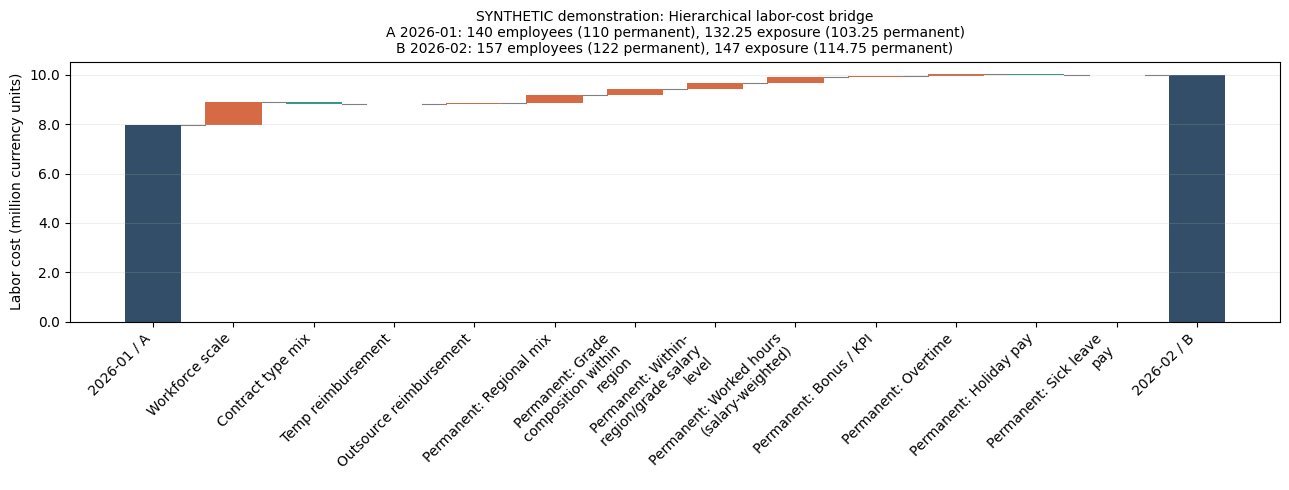

**SYNTHETIC demonstration — Within-region/grade salary level: headline and audit**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: total-cost currency.*

headline_salary_impact   238,242.432632
sum_of_cell_impacts      238,242.432632
audit_error                    0.000000
dtype: float64

**SYNTHETIC demonstration — Salary contribution by region × grade cell**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: counts; pre-regional salary per exposure; unit_impact per permanent exposure; total_impact in total currency.*

,region,grade,count_A,salary_A,source_A,count_B,salary_B,source_B,salary_change,unit_impact,total_impact
0,Central,G1,20,"42,599.060000",observed cell,22,"44,828.020000",observed cell,"2,228.960000",365.080000,"39,793.340000"
1,Central,G2,27,"59,662.830000",observed cell,17,"60,566.980000",observed cell,904.160000,146.160000,"15,931.620000"
2,Central,G3,32,"82,361.990000",observed cell,26,"87,612.940000",observed cell,"5,250.940000","1,146.940000","125,017.230000"
3,Coastal,G1,15,"42,261.610000",observed cell,8,"43,463.170000",observed cell,"1,201.560000",118.890000,"12,959.090000"
4,Coastal,G2,16,"58,775.510000",observed cell,12,"60,351.390000",observed cell,"1,575.880000",189.120000,"20,613.590000"
5,Coastal,G3,0,"82,361.990000",grade,12,"85,072.870000",observed cell,"2,710.870000",133.760000,"14,580.140000"
6,North,G1,0,"42,458.890000",grade,9,"42,105.060000",observed cell,-353.830000,-14.260000,"-1,554.550000"
7,North,G2,0,"59,327.990000",grade,8,"64,820.400000",observed cell,"5,492.400000",203.330000,"22,163.390000"
8,North,G3,0,"82,361.990000",grade,8,"79,497.440000",observed cell,"-2,864.560000",-103.320000,"-11,261.420000"


**SYNTHETIC demonstration — Salary impact by observed/imputed support**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: total-cost currency; net and absolute-impact shares (undefined for zero denominators).*

...

,employee_id,region_A,grade_A,base_salary_A,region_B,grade_B,base_salary_B,base_salary_change,salary_changed,grade_changed,region_changed
0,permanent-0012,Central,G3,"69,914.841324",Coastal,G2,"62,090.861325","-7,823.980000",True,True,True
1,permanent-0013,Coastal,G1,"36,596.355746",North,G1,"48,736.872936","12,140.517190",True,False,True
2,permanent-0014,Coastal,G1,"43,096.353437",Coastal,G3,"96,711.147947","53,614.794510",True,True,False
3,permanent-0015,Central,G3,"81,861.405097",North,G3,"75,563.076762","-6,298.328334",True,False,True
4,permanent-0016,Coastal,G1,"38,052.456277",Central,G3,"98,054.224141","60,001.767864",True,True,True
5,permanent-0017,Coastal,G2,"65,080.350309",Coastal,G1,"49,597.434804","-15,482.915505",True,True,False
6,permanent-0018,Central,G2,"61,490.256796",Central,G2,"66,849.586627","5,359.329830",True,False,False
7,permanent-0019,Central,G2,"62,112.351330",Central,G1,"42,430.398347","-19,681.952983",True,True,False
8,permanent-0020,Coastal,G2,"53,152.130332",North,G2,"71,263.650634","18,111.520302",True,False,True
9,permanent-0021,Central,G2,"52,671.785067",Coastal,G3,"92,232.122785","39,560.337717",True,True,True


**SYNTHETIC demonstration — Entered permanent sample — showing 10 of 24**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: employee records; pre-regional base salary per exposure.*

,employee_id,region,grade,base_salary
238,permanent-0110,Central,G3,"96,595.964375"
239,permanent-0111,Central,G3,"86,177.259807"
240,permanent-0112,North,G2,"57,896.387632"
241,permanent-0113,Central,G1,"41,736.128228"
242,permanent-0114,Coastal,G2,"67,577.921555"
243,permanent-0115,Central,G1,"38,354.244668"
244,permanent-0116,Coastal,G2,"63,016.215699"
245,permanent-0117,Central,G3,"86,193.451152"
246,permanent-0118,Coastal,G1,"47,859.094260"
247,permanent-0119,Central,G3,"96,804.642398"


**SYNTHETIC demonstration — Left permanent sample — showing 10 of 12**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: employee records; pre-regional base salary per exposure.*

,employee_id,region,grade,base_salary
0,permanent-0000,Coastal,G1,"36,876.612412"
1,permanent-0001,Central,G2,"67,166.936554"
2,permanent-0002,Central,G3,"80,398.123525"
3,permanent-0003,Coastal,G1,"45,912.130800"
4,permanent-0004,Central,G3,"72,357.561573"
5,permanent-0005,Central,G1,"46,855.402736"
6,permanent-0006,Central,G2,"51,392.575367"
7,permanent-0007,Central,G2,"58,516.025209"
8,permanent-0008,Central,G2,"51,891.132572"
9,permanent-0009,Central,G3,"81,276.985107"


In [11]:
def final_bridge(permanent, top, multiplier, registry=DRIVERS):
    records = []
    for d in drivers_at('total', registry):
        children = drivers_at(PARENT, registry) if d.name == PARENT else (d,)
        for child in children:
            is_child = child.parent == PARENT
            impact = multiplier*permanent['impacts'][child.name] if is_child else top['impacts'][child.name]
            records.append({'driver': child.name, 'label': child.label, 'parent_driver': child.parent,
                            'level': 2 if is_child else 1, 'impact': impact})
    bridge = pd.DataFrame(records)
    delta = top['end']-top['base']
    bridge['share_of_net_change'] = np.nan if np.isclose(delta, 0, rtol=0, atol=ATOL) else bridge.impact/delta
    return bridge

def waterfall(bridge, start, end, title, *, context):
    impacts = bridge.impact.to_numpy()
    before = start + np.r_[0, np.cumsum(impacts)[:-1]]
    after = before + impacts
    fig, ax = plt.subplots(figsize=(13,5))
    positions = np.arange(1, len(impacts)+1)
    ax.bar(positions, np.abs(impacts), bottom=np.minimum(before,after),
           color=np.where(impacts >= 0, '#d56a45', '#339989'), width=0.7)
    ax.bar([0,len(impacts)+1], [start,end], color='#334e68', width=0.7)
    for x, value in enumerate(np.r_[start,after]):
        ax.plot([x+0.35,x+0.65], [value,value], color='gray', linewidth=0.8)
    labels = [f"{context['periods'][0]:%Y-%m} / A"] + [f'Permanent: {r.label}' if r.level == 2 else r.label for r in bridge.itertuples()] + [f"{context['periods'][1]:%Y-%m} / B"]
    ax.set_xticks(np.arange(len(labels)), [fill(label, 24) for label in labels], rotation=45, ha='right')
    ax.set_ylabel('Labor cost (million currency units)')
    ax.set_title(context['dataset'] + ': ' + title + chr(10) + chr(10).join(context['counts']), fontsize=10)
    ax.yaxis.set_major_formatter(lambda value, position: f'{value/1_000_000:,.1f}')
    ax.grid(axis='y', alpha=0.2)
    fig.tight_layout()
    plt.show()
    return fig

bridge = final_bridge(permanent_game, top_game, M)
show_result(bridge, synthetic_context, 'Final hierarchical bridge', 'total-cost currency; shares of net cost change')
show_result(pd.Series({'period_A_total': top_game['base'], 'period_B_total': top_game['end'],
                   'total_change': top_game['end']-top_game['base'],
                   'reconciliation_error': bridge.impact.sum()-(top_game['end']-top_game['base'])}),
            synthetic_context, 'Bridge endpoints and reconciliation', 'total-cost currency')
_ = waterfall(bridge, top_game['base'], top_game['end'], 'Hierarchical labor-cost bridge', context=synthetic_context)
synthetic_salary_audit, synthetic_matches = show_salary_diagnostics(
    employees, state_A, state_B, permanent_game, M, coverage_A, coverage_B, fallback_A, fallback_B, synthetic_context)


## 12. Diagnostics and validation
Every numerical check below raises on failure and records actual, expected, error, and pass status.
All binary coalitions are explicitly checked, including distributions, salary support and finite
costs. The sparse-cell diagnostic shows the largest **permanent composition share** assigned to
unsupported cells across all composition/driver switches (multiply by permanent exposure for
employee-month units). It is not a claim that those cells occurred historically.

In [12]:
def comparison_record(name, actual, expected):
    np.testing.assert_allclose(actual, expected, rtol=RTOL, atol=ATOL, err_msg=name)
    return {'check': name, 'actual': float(actual), 'expected': float(expected),
            'error': float(actual-expected), 'passed': True}

def reconcile(frame, a, b, permanent, top, multiplier, bridge, periods=(PERIOD_A,PERIOD_B), registry=DRIVERS):
    checks = []
    for period, state in zip(periods, (a,b)):
        rows = frame.loc[frame.period.eq(period)]
        checks.append(comparison_record(f'{period.date()} total modeled vs source', cost(state, registry), rows.source_cost.sum()))
        units = top_state(state, registry)
        rates = [units[PARENT], units['temp_reimbursement'], units['outsource_reimbursement']]
        for idx, contract in enumerate(CONTRACTS):
            modeled = units['workforce_scale']*units['contract_type_mix'][idx]*rates[idx]
            checks.append(comparison_record(f'{period.date()} {contract} subtotal', modeled,
                                           rows.loc[rows.contract_type.eq(contract),'source_cost'].sum()))
    delta = cost(b,registry)-cost(a,registry)
    checks += [comparison_record('top-level SHAP sum', top['impacts'].sum(), delta),
               comparison_record('permanent SHAP sum', permanent['impacts'].sum(), permanent['end']-permanent['base']),
               comparison_record('propagated permanent children', multiplier*permanent['impacts'].sum(), top['impacts'][PARENT]),
               comparison_record('flattened final SHAP sum', bridge.impact.sum(), delta),
               comparison_record('exposure multiplier vs analytical', multiplier, analytical_multiplier(top_state(a,registry),top_state(b,registry)))]
    return pd.DataFrame(checks)

def unsupported_mass(a, b, coverage_a, coverage_b, registry=DRIVERS):
    specs = drivers_at(PARENT, registry)
    pa, pb = a['permanent'], b['permanent']
    shapes = pa['grade_mix_within_region'].shape
    supports = [coverage_a['count'].to_numpy().reshape(shapes)>0, coverage_b['count'].to_numpy().reshape(shapes)>0]
    rows = []
    for d in specs:
        if not d.kind.startswith('cell_'):
            continue
        for period, support in zip((PERIOD_A, PERIOD_B), supports):
            maximum = 0.0
            for region_t, grade_t in product((0,1), repeat=2):
                mix = (pa,pb)[region_t]['regional_mix'][:,None]*(pa,pb)[grade_t]['grade_mix_within_region']
                maximum = max(maximum, float(mix[~support].sum()))
            rows.append({'variable': d.name, 'value_period': period, 'unsupported_cells': int((~support).sum()),
                         'max_counterfactual_permanent_share': maximum})
    return pd.DataFrame(rows)

def audit_coalitions(game):
    switches = np.array(list(product((0,1), repeat=len(game['impacts']))))
    values = game['model'](switches)  # Cost engines validate every complete hybrid.
    assert np.isfinite(values).all()
    return {'coalitions': len(values), 'minimum_cost': values.min(), 'maximum_cost': values.max(), 'passed': True}

def decompose(a, b, registry=DRIVERS):
    ensure_same_policy(a['permanent']['_policy'], b['permanent']['_policy'])
    permanent = exact_game(a['permanent'], b['permanent'], drivers_at(PARENT,registry), lambda s: permanent_cost(s,registry))
    ta, tb = top_state(a,registry), top_state(b,registry)
    top = exact_game(ta, tb, drivers_at('total',registry), lambda s: total_from_units(s,registry))
    multiplier, auxiliary = exposure_multiplier(ta,tb,registry)
    bridge = final_bridge(permanent,top,multiplier,registry)
    return dict(permanent=permanent, top=top, multiplier=multiplier, auxiliary=auxiliary, bridge=bridge)

validation = reconcile(employees,state_A,state_B,permanent_game,top_game,M,bridge)
show_result(validation, synthetic_context, 'Analytical reconciliation', 'currency, permanent-unit currency, or exposure as named in each check')
show_result(pd.DataFrame({name: audit_coalitions(game) for name,game in
                     [('permanent',permanent_game),('top',top_game),('auxiliary',auxiliary_game)]}).T, synthetic_context, 'All-coalition validity', 'coalition counts; unit/total currency according to game')
fallbacks = pd.concat([fallback_A,fallback_B], ignore_index=True)
coverage = pd.concat([coverage_A,coverage_B], ignore_index=True)
show_result(coverage, synthetic_context, 'Region × grade coverage', 'employee counts and exposure')
with pd.option_context('display.max_rows', None):
    show_result(fallbacks, synthetic_context, 'Every fallback use', 'pre-regional eligible pay per exposure; other units as documented in section 5')  # All fallback uses, including values, remain visible in saved output.
show_result(unsupported_mass(state_A,state_B,coverage_A,coverage_B), synthetic_context, 'Unsupported counterfactual cells', 'cell counts and permanent-composition shares')
assert not fallbacks.empty
assert 'period_grade_distribution' in set(fallbacks.fallback_level)
assert (coverage['count'] == 0).any()

**SYNTHETIC demonstration — Analytical reconciliation**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: currency, permanent-unit currency, or exposure as named in each check.*

,check,actual,expected,error,passed
0,2026-01-01 total modeled vs source,"7,952,174.496420","7,952,174.496420",0.000000,True
1,2026-01-01 permanent subtotal,"6,330,273.438495","6,330,273.438495",0.000000,True
2,2026-01-01 temporary subtotal,"860,669.619033","860,669.619033",0.000000,True
3,2026-01-01 outsourced subtotal,"761,231.438892","761,231.438892",0.000000,True
4,2026-02-01 total modeled vs source,"9,978,634.383270","9,978,634.383270",0.000000,True
5,2026-02-01 permanent subtotal,"8,206,272.864200","8,206,272.864200",-0.000000,True
6,2026-02-01 temporary subtotal,"1,181,585.572515","1,181,585.572515",0.000000,True
7,2026-02-01 outsourced subtotal,"590,775.946555","590,775.946555",0.000000,True
8,top-level SHAP sum,"2,026,459.886850","2,026,459.886850",0.000000,True
9,permanent SHAP sum,"10,204.206104","10,204.206104",-0.000000,True


**SYNTHETIC demonstration — All-coalition validity**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: coalition counts; unit/total currency according to game.*

,coalitions,minimum_cost,maximum_cost,passed
permanent,256,"60,799.557248","71,970.710786",True
top,32,"7,894,264.415296","10,053,265.541073",True
auxiliary,32,"1,564,851.195804","1,845,992.142896",True


**SYNTHETIC demonstration — Region × grade coverage**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: employee counts and exposure.*

,region,grade,period,count,exposure
0,Central,G1,2026-01-01,20,19.000000
1,Central,G2,2026-01-01,27,24.750000
2,Central,G3,2026-01-01,32,31.000000
3,Coastal,G1,2026-01-01,15,13.500000
4,Coastal,G2,2026-01-01,16,15.000000
5,Coastal,G3,2026-01-01,0,0.000000
6,North,G1,2026-01-01,0,0.000000
7,North,G2,2026-01-01,0,0.000000
8,North,G3,2026-01-01,0,0.000000
9,Central,G1,2026-02-01,22,21.750000


**SYNTHETIC demonstration — Every fallback use**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: pre-regional eligible pay per exposure; other units as documented in section 5.*

,period,region,grade,variable,fallback_level,fallback_value
0,2026-01-01,North,G1,grade_mix_within_region,period_grade_distribution,0.314770
1,2026-01-01,North,G2,grade_mix_within_region,period_grade_distribution,0.384988
2,2026-01-01,North,G3,grade_mix_within_region,period_grade_distribution,0.300242
3,2026-01-01,Coastal,G3,underlying_salary_level,grade,"82,361.994407"
4,2026-01-01,North,G1,underlying_salary_level,grade,"42,458.887812"
5,2026-01-01,North,G2,underlying_salary_level,grade,"59,327.992465"
6,2026-01-01,North,G3,underlying_salary_level,grade,"82,361.994407"
7,2026-01-01,Coastal,G3,worked_hours,grade,0.837335
8,2026-01-01,North,G1,worked_hours,grade,0.848027
9,2026-01-01,North,G2,worked_hours,grade,0.850818


**SYNTHETIC demonstration — Unsupported counterfactual cells**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: cell counts and permanent-composition shares.*

,variable,value_period,unsupported_cells,max_counterfactual_permanent_share
0,underlying_salary_level,2026-01-01,4,0.291939
1,underlying_salary_level,2026-02-01,0,0.000000
2,worked_hours,2026-01-01,4,0.291939
3,worked_hours,2026-02-01,0,0.000000
4,bonus_kpi,2026-01-01,4,0.291939
5,bonus_kpi,2026-02-01,0,0.000000
6,overtime,2026-01-01,4,0.291939
7,overtime,2026-02-01,0,0.000000
8,holiday_pay,2026-01-01,4,0.291939
9,holiday_pay,2026-02-01,0,0.000000


### Edge cases and failure checks
These tests target accounting and counterfactual failure modes. An identical-state game must
produce zeros; reversing the two-period game must reverse every impact. The zero-parent-change
case transfers 500 pre-regional currency between holiday and sick-leave pay, which share
regional eligibility, leaving offsetting regionally adjusted child impacts.

In [13]:
edge_checks = []
def check_vector(name, actual, expected):
    np.testing.assert_allclose(actual, expected, rtol=RTOL, atol=ATOL, err_msg=name)
    edge_checks.append({'check': name, 'passed': True})

def expect_invalid(name, action):
    try:
        action()
    except (ValueError, KeyError) as exc:
        edge_checks.append({'check': name, 'passed': True, 'detail': str(exc)})
    else:
        raise AssertionError(f'{name}: invalid input accepted')

identical = decompose(state_A,state_A)
check_vector('identical periods: zero bridge', identical['bridge'].impact, 0)
assert identical['bridge'].share_of_net_change.isna().all()
reverse = decompose(state_B,state_A)
check_vector('reverse top impacts', reverse['top']['impacts'], -top_game['impacts'])
check_vector('reverse permanent impacts', reverse['permanent']['impacts'], -permanent_game['impacts'])
check_vector('reverse final impacts', reverse['bridge'].impact, -bridge.impact)

salary_only = deepcopy(state_A)
salary_only['permanent']['underlying_salary_level'] *= 1.03
one_change = decompose(state_A,salary_only)
check_vector('unchanged permanent drivers are zero', one_change['permanent']['impacts'].drop('underlying_salary_level'), 0)
check_vector('unchanged top drivers are zero', one_change['top']['impacts'].drop(PARENT), 0)

offset_a, offset_b = deepcopy(state_A), deepcopy(state_A)
offset_a['permanent']['holiday_pay'][:] = 1500
offset_a['permanent']['sick_leave_pay'][:] = 1500
offset_b = deepcopy(offset_a)
offset_b['permanent']['holiday_pay'] += 500
offset_b['permanent']['sick_leave_pay'] -= 500
offset = decompose(offset_a,offset_b)
check_vector('zero parent change', offset['top']['impacts'][PARENT], 0)
offset_unit = 500*np.dot(offset_a['permanent']['regional_mix'], policy['regional_coefficients'])
check_vector('offsetting eligible children in unit currency',
             offset['permanent']['impacts'][['holiday_pay','sick_leave_pay']], [offset_unit,-offset_unit])
check_vector('offsetting children reconcile in total currency', offset['bridge'].impact.sum(), 0)
check_vector('zero delta has finite exposure multiplier', offset['multiplier'], analytical_multiplier(top_state(offset_a),top_state(offset_b)))

invalid_top = dict(top_A, contract_type_mix=np.array([0.8,0.3,0.1]))
expect_invalid('invalid contract probabilities', lambda: total_from_units(invalid_top))
for key, replacement in [('regional_mix', np.array([0.2,0.2,0.2])),
                         ('grade_mix_within_region', np.zeros_like(state_A['permanent']['grade_mix_within_region'])),
                         ('underlying_salary_level', np.full_like(state_A['permanent']['underlying_salary_level'], np.nan))]:
    bad = dict(state_A['permanent'], **{key:replacement})
    expect_invalid(f'invalid {key}', lambda bad=bad: permanent_cost(bad))
expect_invalid('fractional switches', lambda: permanent_game['model'](np.full((1,len(permanent_game['impacts'])),0.5)))
expect_invalid('missing input column', lambda: build_state(employees.drop(columns='worked_fraction'),PERIOD_A,policy))
expect_invalid('duplicate employee-month', lambda: build_state(pd.concat([employees,employees.iloc[:1]]),PERIOD_A,policy))
bad_input = employees.copy()
bad_input.loc[0,'region'] = 'Unknown'
expect_invalid('unknown region', lambda: build_state(bad_input,PERIOD_A,policy))
expect_invalid('invalid coefficient', lambda: make_policy(employees, {'Central': 0}))
expect_invalid('disabled fallback cannot support sparse cells', lambda: build_state(employees,PERIOD_A,policy,fallback_order=()))
# A declared but unobserved grade exercises region and global fallback levels as well.
extra_grade_policy = make_policy(employees, REGIONAL_COEFFICIENTS, grades=policy['grades']+('G4',))
extra_grade_state, extra_grade_log, _ = build_state(employees,PERIOD_A,extra_grade_policy)
assert {'grade','region','global'} <= set(extra_grade_log.fallback_level)
check_vector('all fallback levels preserve the observed endpoint', cost(extra_grade_state), cost(state_A))
edge_checks.append({'check':'grade / region / global fallbacks all exercised', 'passed':True})
bad_salary = employees.copy()
bad_salary.loc[0,'base_salary'] = np.nan
expect_invalid('unknown base salary is rejected', lambda: build_state(bad_salary,PERIOD_A,policy))
without_temp = employees.loc[~employees.contract_type.eq('temporary')]
expect_invalid('missing contract without reference', lambda: build_state(without_temp,PERIOD_A,policy))
referenced, reference_log, _ = build_state(without_temp,PERIOD_A,policy,references={'temporary': 50000})
check_vector('explicit temporary reference preserves observed endpoint', cost(referenced), without_temp.loc[without_temp.period.eq(PERIOD_A),'source_cost'].sum())
assert 'business_reference' in set(reference_log.fallback_level)
without_perm = employees.loc[~employees.contract_type.eq('permanent')]
expect_invalid('no permanent population or reference', lambda: build_state(without_perm,PERIOD_A,policy))
referenced_perm, perm_reference_log, _ = build_state(without_perm,PERIOD_A,policy,references={'permanent':state_A['permanent']})
check_vector('complete permanent reference preserves zero-permanent endpoint', cost(referenced_perm), without_perm.loc[without_perm.period.eq(PERIOD_A),'source_cost'].sum())
changed_policy = deepcopy(state_B)
changed_policy['permanent']['_policy']['regional_coefficients'][0] += 0.1
expect_invalid('policy change cannot masquerade as a driver', lambda: decompose(state_A,changed_policy))
show_result(pd.DataFrame(edge_checks), synthetic_context, 'Validation scenarios derived from this example', 'pass/fail checks')

# Diagnostic edge cases: zero salary change and no matched permanent IDs.
zero_audit = salary_cell_audit(state_A,state_A,identical['permanent'],identical['multiplier'],
                               coverage_A,coverage_A,fallback_A,fallback_A)
check_vector('salary audit has zero impact for identical states',zero_audit.total_impact,0)
assert salary_support_summary(zero_audit).share_of_net_impact.isna().all()
assert salary_support_summary(zero_audit).share_of_absolute_impacts.isna().all()
no_matches = employees.copy()
no_matches.loc[no_matches.period.eq(PERIOD_B),'employee_id'] += '-new-id'
empty_match = matched_salary_diagnostic(no_matches)
assert empty_match['matched'].empty and empty_match['summary']['matched_permanent_employees'] == 0
show_result(pd.DataFrame([{'check':'zero-impact audit shares are undefined','passed':True},
                          {'check':'no matched employees produces an empty diagnostic','passed':True}]),
            synthetic_context, 'Salary diagnostic edge cases', 'pass/fail checks')

nullable_match_input = employees.copy()
nullable_match_input['base_salary'] = nullable_match_input.base_salary.astype('Float64')
pd.testing.assert_series_equal(matched_salary_diagnostic(nullable_match_input)['summary'],synthetic_matches['summary'])


**SYNTHETIC demonstration — Validation scenarios derived from this example**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: pass/fail checks.*

,check,passed,detail
0,identical periods: zero bridge,True,NaN
1,reverse top impacts,True,NaN
2,reverse permanent impacts,True,NaN
3,reverse final impacts,True,NaN
4,unchanged permanent drivers are zero,True,NaN
5,unchanged top drivers are zero,True,NaN
6,zero parent change,True,NaN
7,offsetting eligible children in unit currency,True,NaN
8,offsetting children reconcile in total currency,True,NaN
9,zero delta has finite exposure multiplier,True,NaN


**SYNTHETIC demonstration — Salary diagnostic edge cases**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: pass/fail checks.*

,check,passed
0,zero-impact audit shares are undefined,True
1,no matched employees produces an empty diagnostic,True


### Regional adjustment: hand calculation, normalization and composition
For one full exposure, base salary 50,000 × worked fraction 0.8, sick leave 2,000 and holiday
pay 3,000 with coefficient 1.2 yield 54,000. Bonus/KPI 1,000 and overtime 500 add 1,500,
giving **55,500**. They do not receive the coefficient under this PoC's policy.

The checks below also regionalize then normalize equivalent source columns, compare every state
driver and fallback value (including region/global fallbacks), and verify identical attribution.
A pure regional-mix change must capture changes in all eligible components without assigning
impacts to unchanged salary or payment drivers.

In [14]:
regional_checks = []
def regional_check(name, actual, expected):
    np.testing.assert_allclose(actual, expected, rtol=RTOL, atol=ATOL, err_msg=name)
    regional_checks.append({'check': name, 'max_abs_error': float(np.max(np.abs(np.asarray(actual)-np.asarray(expected)))), 'passed': True})

# Tiny state constructed directly: the cost engine needs no historical data or SHAP.
hand = {
    '_policy': {'regions': ('Example',), 'grades': ('G1',), 'regional_coefficients': np.array([1.2])},
    'regional_mix': np.array([1.0]), 'grade_mix_within_region': np.array([[1.0]]),
    'underlying_salary_level': np.array([[50000.0]]), 'worked_hours': np.array([[0.8]]),
    'sick_leave_pay': np.array([[2000.0]]), 'holiday_pay': np.array([[3000.0]]),
    'bonus_kpi': np.array([[1000.0]]), 'overtime': np.array([[500.0]])}
regional_check('hand-calculated permanent cost', permanent_cost(hand), 55500.0)
for component, expected_reduction in [('sick_leave_pay',2400.0), ('holiday_pay',3600.0),
                                      ('bonus_kpi',1000.0), ('overtime',500.0)]:
    removed = deepcopy(hand)
    removed[component][:] = 0
    regional_check(f'{component}: eligibility applied exactly once', permanent_cost(hand)-permanent_cost(removed), expected_reduction)

adjusted_columns = ('base_salary','sick_leave_pay','holiday_pay')
adjusted_source = employees.copy()
permanent_rows = adjusted_source.contract_type.eq('permanent')
source_factors = adjusted_source.loc[permanent_rows,'region'].map(REGIONAL_COEFFICIENTS)
adjusted_source.loc[permanent_rows, list(adjusted_columns)] = adjusted_source.loc[permanent_rows, list(adjusted_columns)].mul(source_factors, axis=0)
adjusted_snapshot = adjusted_source.copy(deep=True)
normalized_source = normalize_regional_inputs(adjusted_source, policy, already_regionalized=adjusted_columns)
pd.testing.assert_frame_equal(adjusted_source, adjusted_snapshot)
pd.testing.assert_frame_equal(normalized_source, employees, rtol=RTOL, atol=ATOL)
pd.testing.assert_series_equal(normalized_source.source_cost, adjusted_source.source_cost, check_exact=True)
regional_checks.append({'check':'normalization preserves source totals and input object', 'max_abs_error':0.0, 'passed':True})

normalized_states = []
for period, original in zip((PERIOD_A,PERIOD_B), (state_A,state_B)):
    normalized, normalized_log, _ = build_state(normalized_source,period,policy)
    normalized_states.append(normalized)
    for driver in drivers_at(PARENT):
        regional_check(f'{period.date()} normalized state: {driver.name}', normalized['permanent'][driver.name], original['permanent'][driver.name])
    regional_check(f'{period.date()} normalized cost', cost(normalized), cost(original))
    original_log = fallback_A if period == PERIOD_A else fallback_B
    pd.testing.assert_frame_equal(normalized_log, original_log, rtol=RTOL, atol=ATOL)
normalized_result = decompose(*normalized_states)
regional_check('normalization preserves permanent SHAP', normalized_result['permanent']['impacts'], permanent_game['impacts'])
regional_check('normalization preserves top SHAP', normalized_result['top']['impacts'], top_game['impacts'])
regional_check('normalization preserves final bridge', normalized_result['bridge'].impact, bridge.impact)

# Exercise grade, region and global fallbacks with the declared but unobserved G4 axis.
normalized_sparse, normalized_sparse_log, _ = build_state(normalized_source,PERIOD_A,extra_grade_policy)
pd.testing.assert_frame_equal(normalized_sparse_log, extra_grade_log, rtol=RTOL, atol=ATOL)
for driver in drivers_at(PARENT):
    regional_check(f'normalization preserves all fallbacks: {driver.name}', normalized_sparse['permanent'][driver.name], extra_grade_state['permanent'][driver.name])

# January has no North observations. Grade fallback must average pre-regional pay.
grade = policy['grades'][0]
north_index = policy['regions'].index('North')
donors = employees.loc[employees.period.eq(PERIOD_A) & employees.contract_type.eq('permanent') & employees.grade.eq(grade)]
fallback_holiday = float(np.average(donors.holiday_pay,weights=donors.exposure))
regional_check('cross-region fallback uses pre-regional holiday amounts', state_A['permanent']['holiday_pay'][north_index,0], fallback_holiday)
north_only = deepcopy(state_A['permanent'])
north_only['regional_mix'] = np.array([0.0,0.0,1.0])
north_only['grade_mix_within_region'][:] = np.array([1.0,0.0,0.0])
without_holiday = deepcopy(north_only)
without_holiday['holiday_pay'][:] = 0
regional_check('fallback receives destination North coefficient once', permanent_cost(north_only)-permanent_cost(without_holiday), fallback_holiday*1.35)

# Only region shares change: all pay/time/grade matrices are identical across regions and periods.
regional_a = deepcopy(state_A)
for key,value in [('underlying_salary_level',50000),('worked_hours',0.8),('sick_leave_pay',2000),
                  ('holiday_pay',3000),('bonus_kpi',1000),('overtime',500)]:
    regional_a['permanent'][key][:] = value
regional_a['permanent']['regional_mix'] = np.array([1.0,0.0,0.0])
regional_b = deepcopy(regional_a)
regional_b['permanent']['regional_mix'] = np.array([0.0,0.0,1.0])
regional_only = decompose(regional_a,regional_b)
expected_unit_change = (1.35-1.0)*(50000*0.8+2000+3000)
regional_check('regional mix includes salary, sick leave and holiday pay', regional_only['permanent']['impacts']['regional_mix'], expected_unit_change)
regional_check('unchanged payment drivers receive no regional-only impact', regional_only['permanent']['impacts'].drop('regional_mix'), 0)
regional_check('regional-only total propagation', regional_only['bridge'].impact.sum(), expected_unit_change*state_A['workforce_scale']*state_A['contract_type_mix'][0])

expect_invalid('normalization rejects ineligible components', lambda: normalize_regional_inputs(employees,policy,('overtime_pay',)))
expect_invalid('normalization rejects duplicate columns', lambda: normalize_regional_inputs(employees,policy,('base_salary','base_salary')))
expect_invalid('normalization rejects unknown regions', lambda: normalize_regional_inputs(bad_input,policy,('base_salary',)))
expect_invalid('normalization rejects missing values', lambda: normalize_regional_inputs(bad_salary,policy,('base_salary',)))
expect_invalid('normalization rejects missing columns', lambda: normalize_regional_inputs(employees.drop(columns='base_salary'),policy,('base_salary',)))
invalid_normalization_policy = deepcopy(policy)
invalid_normalization_policy['regional_coefficients'][0] = 0
expect_invalid('normalization rejects invalid coefficients', lambda: normalize_regional_inputs(employees,invalid_normalization_policy,('base_salary',)))
nullable_salary = employees.copy()
nullable_salary['base_salary'] = nullable_salary.base_salary.astype('Float64')
nullable_salary.loc[0,'base_salary'] = pd.NA
expect_invalid('normalization rejects nullable missing values', lambda: normalize_regional_inputs(nullable_salary,policy,('base_salary',)))
expect_invalid('state builder rejects nullable missing values', lambda: build_state(nullable_salary,PERIOD_A,policy))
show_result(pd.DataFrame(regional_checks), synthetic_context, 'Regional-rule validation scenarios', 'max absolute errors; hand example and synthetic-derived scenarios')
show_result(pd.DataFrame(edge_checks[-8:]), synthetic_context, 'Normalization failure checks', 'pass/fail checks')

**SYNTHETIC demonstration — Regional-rule validation scenarios**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: max absolute errors; hand example and synthetic-derived scenarios.*

,check,max_abs_error,passed
0,hand-calculated permanent cost,0.000000,True
1,sick_leave_pay: eligibility applied exactly once,0.000000,True
2,holiday_pay: eligibility applied exactly once,0.000000,True
3,bonus_kpi: eligibility applied exactly once,0.000000,True
4,overtime: eligibility applied exactly once,0.000000,True
5,normalization preserves source totals and inpu...,0.000000,True
6,2026-01-01 normalized state: regional_mix,0.000000,True
7,2026-01-01 normalized state: grade_mix_within_...,0.000000,True
8,2026-01-01 normalized state: underlying_salary...,0.000000,True
9,2026-01-01 normalized state: worked_hours,0.000000,True


**SYNTHETIC demonstration — Normalization failure checks**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: pass/fail checks.*

,check,passed,detail
0,normalization rejects ineligible components,True,Normalization columns must be unique and regio...
1,normalization rejects duplicate columns,True,Normalization columns must be unique and regio...
2,normalization rejects unknown regions,True,Unknown/missing region for input normalization
3,normalization rejects missing values,True,Invalid normalization values: base_salary
4,normalization rejects missing columns,True,Missing normalization columns: ['base_salary']
5,normalization rejects invalid coefficients,True,Invalid normalization coefficient policy
6,normalization rejects nullable missing values,True,Invalid normalization values: base_salary
7,state builder rejects nullable missing values,True,base_salary must be finite and nonnegative


<a id="mock-data-results"></a>

### Supplementary supplied mock: Jan–Feb fixture → canonical DataFrame
This optional adapter reads `costs_poc.csv`, whose text contains literal escaped CRLF separators
and decimal commas. Production data are DataFrames; parsing is not part of the analytical model.

Confirmed inputs: mock `base salary`, `sick leave`, and `holiday pay` are all **before regional
adjustment**. They map directly to canonical fields. The reference payroll multiplies their
combined eligible amount by the coefficient once, with utilization applied only to salary.
The reconstructed totals are **494,716.700 in January** and **625,148.125 in February**.

Coefficient bands are proxy regions, not identified geographic locations. We map ТК/ГПХ/ПКЦ
to permanent/temporary/outsourced, use exposure 1 per employee-month, and interpret utilization
as paid-time fraction. Blank sick/holiday amounts mean no recorded payment. Bonus/KPI and
overtime are unavailable and explicitly modeled as absent. This fixture has a limited driver set.

There is no independent source total: its payroll reference is reconstructed using these
assumptions. Reconciliation verifies the aggregation, not the assumptions themselves.

**The following outputs use the supplied MOCK data.** Their salary changes differ from the
synthetic example above. The accompanying audit distinguishes within-cell workforce changes
from salary changes among continuing employees.


**MOCK costs_poc.csv — reconstructed payroll — Analytical reconciliation**  
A 2026-01: 13 employees (10 permanent), 13 exposure (10 permanent) · B 2026-02: 16 employees (10 permanent), 16 exposure (10 permanent)

*Units: currency, permanent-unit currency, or exposure as named in each check.*

,check,actual,expected,error,passed
0,2026-01-01 total modeled vs source,"494,716.700000","494,716.700000",-0.000000,True
1,2026-01-01 permanent subtotal,"358,046.700000","358,046.700000",-0.000000,True
2,2026-01-01 temporary subtotal,"100,000.000000","100,000.000000",0.000000,True
3,2026-01-01 outsourced subtotal,"36,670.000000","36,670.000000",0.000000,True
4,2026-02-01 total modeled vs source,"625,148.125000","625,148.125000",0.000000,True
5,2026-02-01 permanent subtotal,"351,808.125000","351,808.125000",0.000000,True
6,2026-02-01 temporary subtotal,"200,000.000000","200,000.000000",0.000000,True
7,2026-02-01 outsourced subtotal,"73,340.000000","73,340.000000",0.000000,True
8,top-level SHAP sum,"130,431.425000","130,431.425000",0.000000,True
9,permanent SHAP sum,-623.857500,-623.857500,0.000000,True


**MOCK costs_poc.csv — reconstructed payroll — Final hierarchical bridge**  
A 2026-01: 13 employees (10 permanent), 13 exposure (10 permanent) · B 2026-02: 16 employees (10 permanent), 16 exposure (10 permanent)

*Units: total-cost currency; shares of net cost change.*

,driver,label,parent_driver,level,impact,share_of_net_change
0,workforce_scale,Workforce scale,total,1,"115,645.343149",0.886637
1,contract_type_mix,Contract type mix,total,1,"21,069.646575",0.161538
2,temp_reimbursement,Temp reimbursement,total,1,0.000000,0.000000
3,outsource_reimbursement,Outsource reimbursement,total,1,-0.000000,-0.000000
4,regional_mix,Regional mix,permanent_unit_cost,2,"3,342.449695",0.025626
5,grade_mix_within_region,Grade composition within region,permanent_unit_cost,2,"-35,330.123692",-0.270871
6,underlying_salary_level,Within-region/grade salary level,permanent_unit_cost,2,11.357247,0.000087
7,worked_hours,Worked hours (salary-weighted),permanent_unit_cost,2,"18,655.490908",0.143029
8,bonus_kpi,Bonus / KPI,permanent_unit_cost,2,0.000000,0.000000
9,overtime,Overtime,permanent_unit_cost,2,0.000000,0.000000


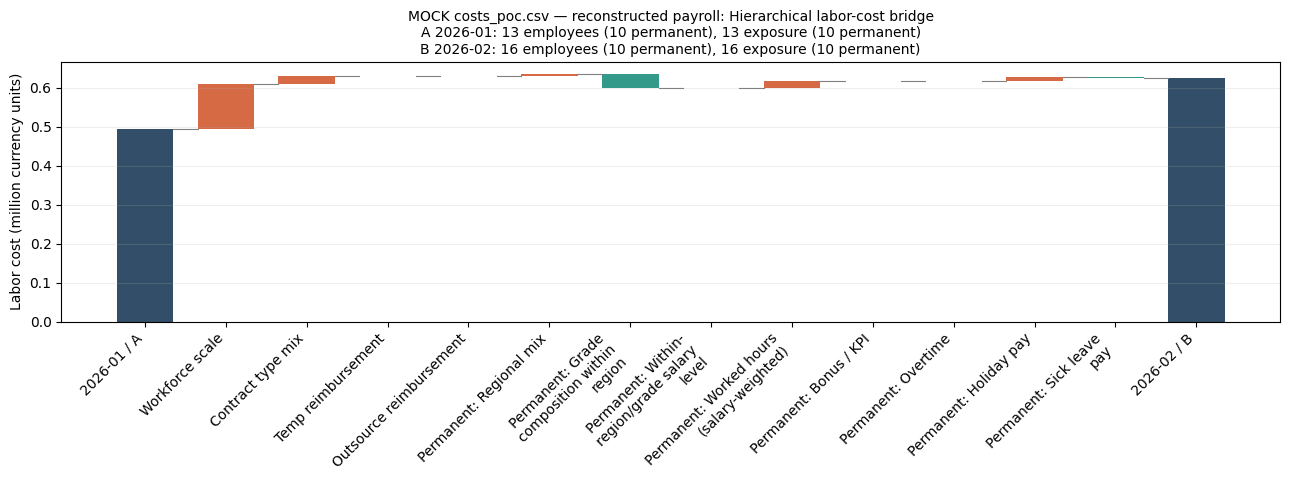

**MOCK costs_poc.csv — reconstructed payroll — Within-region/grade salary level: headline and audit**  
A 2026-01: 13 employees (10 permanent), 13 exposure (10 permanent) · B 2026-02: 16 employees (10 permanent), 16 exposure (10 permanent)

*Units: total-cost currency.*

headline_salary_impact   11.357247
sum_of_cell_impacts      11.357247
audit_error              -0.000000
dtype: float64

**MOCK costs_poc.csv — reconstructed payroll — Salary contribution by region × grade cell**  
A 2026-01: 13 employees (10 permanent), 13 exposure (10 permanent) · B 2026-02: 16 employees (10 permanent), 16 exposure (10 permanent)

*Units: counts; pre-regional salary per exposure; unit_impact per permanent exposure; total_impact in total currency.*

,region,grade,count_A,salary_A,source_A,count_B,salary_B,source_B,salary_change,unit_impact,total_impact
0,Coefficient band 0.75,G10,0,"45,000.000000",grade,1,"45,000.000000",observed cell,0.000000,0.000000,0.000000
1,Coefficient band 0.75,G11,0,"54,000.000000",grade,0,"53,000.000000",grade,"-1,000.000000",0.000000,0.000000
2,Coefficient band 0.75,G12,0,"63,750.000000",grade,2,"63,750.000000",observed cell,0.000000,0.000000,0.000000
3,Coefficient band 0.75,G13,2,"75,000.000000",observed cell,1,"75,000.000000",observed cell,0.000000,0.000000,0.000000
4,Coefficient band 0.75,G9,1,"37,500.000000",observed cell,1,"37,500.000000",observed cell,0.000000,0.000000,0.000000
5,Coefficient band 0.9,G10,1,"45,000.000000",observed cell,1,"45,000.000000",observed cell,0.000000,0.000000,0.000000
6,Coefficient band 0.9,G11,2,"54,500.000000",observed cell,1,"53,000.000000",observed cell,"-1,500.000000",-137.980000,"-1,389.750000"
7,Coefficient band 0.9,G12,0,"63,750.000000",grade,0,"63,750.000000",grade,0.000000,0.000000,0.000000
8,Coefficient band 0.9,G13,0,"75,000.000000",grade,0,"75,000.000000",grade,0.000000,0.000000,0.000000
9,Coefficient band 0.9,G9,0,"37,500.000000",grade,0,"37,500.000000",grade,0.000000,0.000000,0.000000


**MOCK costs_poc.csv — reconstructed payroll — Salary impact by observed/imputed support**  
A 2026-01: 13 employees (10 permanent), 13 exposure (10 permanent) · B 2026-02: 16 employees (10 permanent), 16 exposure (10 permanent)

*Units: total-cost currency; net and absolute-impact shares (undefined for zero denominators).*

...

,period,region,grade,variable,fallback_level,fallback_value
0,2026-01-01,Coefficient band 0.75,G10,underlying_salary_level,grade,"45,000.000000"
1,2026-01-01,Coefficient band 0.75,G11,underlying_salary_level,grade,"54,000.000000"
2,2026-01-01,Coefficient band 0.75,G12,underlying_salary_level,grade,"63,750.000000"
3,2026-01-01,Coefficient band 0.9,G12,underlying_salary_level,grade,"63,750.000000"
4,2026-01-01,Coefficient band 0.9,G13,underlying_salary_level,grade,"75,000.000000"
5,2026-01-01,Coefficient band 0.9,G9,underlying_salary_level,grade,"37,500.000000"
6,2026-01-01,Coefficient band 1,G13,underlying_salary_level,grade,"75,000.000000"
7,2026-01-01,Coefficient band 0.75,G10,worked_hours,grade,0.685000
8,2026-01-01,Coefficient band 0.75,G11,worked_hours,grade,0.733827
9,2026-01-01,Coefficient band 0.75,G12,worked_hours,grade,0.970000


**MOCK costs_poc.csv — reconstructed payroll — Unsupported counterfactual cells**  
A 2026-01: 13 employees (10 permanent), 13 exposure (10 permanent) · B 2026-02: 16 employees (10 permanent), 16 exposure (10 permanent)

*Units: cell counts and permanent-composition shares.*

,variable,value_period,unsupported_cells,max_counterfactual_permanent_share
0,underlying_salary_level,2026-01-01,7,0.300000
1,underlying_salary_level,2026-02-01,8,0.300000
2,worked_hours,2026-01-01,7,0.300000
3,worked_hours,2026-02-01,8,0.300000
4,bonus_kpi,2026-01-01,7,0.300000
5,bonus_kpi,2026-02-01,8,0.300000
6,overtime,2026-01-01,7,0.300000
7,overtime,2026-02-01,8,0.300000
8,holiday_pay,2026-01-01,7,0.300000
9,holiday_pay,2026-02-01,8,0.300000


**MOCK costs_poc.csv — reconstructed payroll — Ordinary salary × time averaging error**  
A 2026-01: 13 employees (10 permanent), 13 exposure (10 permanent) · B 2026-02: 16 employees (10 permanent), 16 exposure (10 permanent)

*Units: total-cost currency.*

,period,ordinary_mean_salary_error
0,2026-01-01,-40.500000
1,2026-02-01,-91.666667


In [15]:
def adapt_mock(raw):
    mapping = {'ТК':'permanent', 'ГПХ':'temporary', 'ПКЦ':'outsourced'}
    if not raw.contract_type.isin(mapping).all():
        raise ValueError('Unrecognized mock contract type')
    out = pd.DataFrame({'period': pd.to_datetime(raw.period), 'employee_id': raw.employee_id,
                        'contract_type': raw.contract_type.map(mapping), 'exposure': 1.0})
    is_perm = out.contract_type.eq('permanent')
    coefficients = pd.to_numeric(raw['regional coefficient'],errors='raise')
    if not np.isfinite(coefficients[is_perm]).all() or (coefficients[is_perm] <= 0).any():
        raise ValueError('Invalid mock regional coefficient')
    bands = {f'Coefficient band {v:g}': float(v) for v in sorted(coefficients[is_perm].unique())}
    out['region'] = coefficients.map(lambda v: f'Coefficient band {v:g}' if pd.notna(v) else None)
    out['grade'] = raw.grade.map(lambda g: f'G{int(g)}' if pd.notna(g) else None)
    out['base_salary'] = raw['base salary']
    out['worked_fraction'] = raw.capacity_utilization
    out['bonus_base'], out['kpi_achievement'], out['overtime_pay'] = 0.0, 0.0, 0.0
    out['holiday_pay'] = raw['holiday pay'].fillna(0)
    out['sick_leave_pay'] = raw['sick leave'].fillna(0)
    out['contract_reimbursement'] = raw.contract_remuneration
    out['source_cost'] = np.where(is_perm,
        coefficients*(out.base_salary*out.worked_fraction + out.holiday_pay+out.sick_leave_pay),
        out.contract_reimbursement)
    return out, bands

mock_path = Path('costs_poc.csv')
if mock_path.exists():
    raw_mock = pd.read_csv(StringIO(mock_path.read_text().replace('\\r\\n','\n')),decimal=',')
    mock, mock_coefficients = adapt_mock(raw_mock)
    mock_context = result_context(mock, 'MOCK costs_poc.csv — reconstructed payroll')
    mock_policy = make_policy(mock,mock_coefficients)
    mock_A, mock_fa, mock_ca = build_state(mock,PERIOD_A,mock_policy)
    mock_B, mock_fb, mock_cb = build_state(mock,PERIOD_B,mock_policy)
    mock_result = decompose(mock_A,mock_B)
    np.testing.assert_allclose([cost(mock_A),cost(mock_B)], [494716.700,625148.125], rtol=RTOL,atol=ATOL)
    show_result(reconcile(mock,mock_A,mock_B,mock_result['permanent'],mock_result['top'],mock_result['multiplier'],mock_result['bridge']),
                mock_context, 'Analytical reconciliation', 'currency, permanent-unit currency, or exposure as named in each check')
    show_result(mock_result['bridge'], mock_context, 'Final hierarchical bridge', 'total-cost currency; shares of net cost change')
    _ = waterfall(mock_result['bridge'],mock_result['top']['base'],mock_result['top']['end'],
                  'Hierarchical labor-cost bridge', context=mock_context)
    mock_salary_audit, mock_matches = show_salary_diagnostics(mock,mock_A,mock_B,mock_result['permanent'],
        mock_result['multiplier'],mock_ca,mock_cb,mock_fa,mock_fb,mock_context)
    assert mock_matches['summary']['matched_permanent_employees'] == 5
    assert mock_matches['summary']['higher_base_salary'] == 0
    assert mock_matches['summary']['lower_base_salary'] == 0
    mock_cells = mock_salary_audit.set_index(['region','grade'])
    np.testing.assert_allclose(
        mock_cells.loc[[('Coefficient band 1','G10'),('Coefficient band 0.9','G11')],'total_impact'],
        [1401.108190,-1389.750943],rtol=RTOL,atol=ATOL)
    with pd.option_context('display.max_rows', None):
        show_result(pd.concat([mock_fa,mock_fb],ignore_index=True), mock_context, 'Every fallback use', 'pre-regional eligible pay per exposure; other units as documented in section 5')
    show_result(unsupported_mass(mock_A,mock_B,mock_ca,mock_cb), mock_context, 'Unsupported counterfactual cells', 'cell counts and permanent-composition shares')
    # Verify why ordinary hours means cannot replace the salary-weighted estimator.
    ordinary_errors = []
    for period in (PERIOD_A,PERIOD_B):
        p = mock.loc[mock.period.eq(period) & mock.contract_type.eq('permanent')]
        naive = p.groupby(['region','grade']).apply(lambda r: r.exposure.sum()*mock_coefficients[r.region.iloc[0]]*weighted_mean(r,r.base_salary)*weighted_mean(r,r.worked_fraction)).sum()
        true_salary = (p.exposure*p.base_salary*p.worked_fraction*p.region.map(mock_coefficients)).sum()
        ordinary_errors.append(naive-true_salary)
    np.testing.assert_allclose(ordinary_errors,[-40.5,-91.6666666667],rtol=RTOL,atol=ATOL)
    show_result(pd.DataFrame({'period':[PERIOD_A,PERIOD_B], 'ordinary_mean_salary_error':ordinary_errors}),
                mock_context, 'Ordinary salary × time averaging error', 'total-cost currency')
else:
    print('Optional costs_poc.csv absent; standalone synthetic demonstration is complete.')

## 13. Add a new permanent driver: night-shift premium
Only two localized changes are needed: supply the payment column/source payroll and append
one registry entry. The hypothetical premium is **pre-regional currency per full exposure** and
opts into regional adjustment. Its source payroll increment independently includes that same
coefficient. There is no separate hard-coded North premium; regional policy is explicit.

No edits to state building, normalization, the cost engine, switch model, propagation,
reporting, validation, or plotting follow. The registry's `cell_cost` callback can also describe
an interacting payment formula using other state drivers, without changing this infrastructure.

In [16]:
# Change 1: pre-regional source field and independently calculated source payroll increment.
extended_employees = employees.copy()
extended_permanent = extended_employees.contract_type.eq('permanent')
extended_employees['night_shift_premium'] = np.where(
    extended_permanent, np.where(extended_employees.period.eq(PERIOD_B), 2100.0, 900.0), 0.0)
extended_employees.loc[extended_permanent, 'source_cost'] += (
    extended_employees.loc[extended_permanent, 'exposure']
    * extended_employees.loc[extended_permanent, 'night_shift_premium']
    * extended_employees.loc[extended_permanent, 'region'].map(REGIONAL_COEFFICIENTS))

# Change 2: one registry entry declares aggregation, payroll contribution, and regional eligibility.
EXTENDED_DRIVERS = DRIVERS + (payment_driver(
    'night_shift_premium', 'Night-shift premium', ('night_shift_premium',),
    lambda r: r.night_shift_premium, apply_regional_coefficient=True),)

**SYNTHETIC + night-shift premium — Analytical reconciliation**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: currency, permanent-unit currency, or exposure as named in each check.*

,check,actual,expected,error,passed
0,2026-01-01 total modeled vs source,"8,048,946.996420","8,048,946.996420",0.000000,True
1,2026-01-01 permanent subtotal,"6,427,045.938495","6,427,045.938495",-0.000000,True
2,2026-01-01 temporary subtotal,"860,669.619033","860,669.619033",0.000000,True
3,2026-01-01 outsourced subtotal,"761,231.438892","761,231.438892",0.000000,True
4,2026-02-01 total modeled vs source,"10,245,491.883270","10,245,491.883270",0.000000,True
5,2026-02-01 permanent subtotal,"8,473,130.364200","8,473,130.364200",-0.000000,True
6,2026-02-01 temporary subtotal,"1,181,585.572515","1,181,585.572515",0.000000,True
7,2026-02-01 outsourced subtotal,"590,775.946555","590,775.946555",0.000000,True
8,top-level SHAP sum,"2,196,544.886850","2,196,544.886850",-0.000000,True
9,permanent SHAP sum,"11,592.497737","11,592.497737",-0.000000,True


**SYNTHETIC + night-shift premium — Final hierarchical bridge**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: total-cost currency; shares of net cost change.*

,driver,label,parent_driver,level,impact,share_of_net_change
0,workforce_scale,Workforce scale,total,1,"963,043.328976",0.438436
1,contract_type_mix,Contract type mix,total,1,"-66,123.346601",-0.030103
2,temp_reimbursement,Temp reimbursement,total,1,"7,843.852343",0.003571
3,outsource_reimbursement,Outsource reimbursement,total,1,"28,195.775336",0.012836
4,regional_mix,Regional mix,permanent_unit_cost,2,"330,851.484169",0.150624
5,grade_mix_within_region,Grade composition within region,permanent_unit_cost,2,"238,985.991305",0.108801
6,underlying_salary_level,Within-region/grade salary level,permanent_unit_cost,2,"238,242.432632",0.108462
7,worked_hours,Worked hours (salary-weighted),permanent_unit_cost,2,"235,811.618245",0.107356
8,bonus_kpi,Bonus / KPI,permanent_unit_cost,2,"59,666.446627",0.027164
9,overtime,Overtime,permanent_unit_cost,2,"71,974.685050",0.032767


**SYNTHETIC + night-shift premium — New premium fallbacks**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: pre-regional currency per exposure.*

,period,region,grade,variable,fallback_level,fallback_value
27,2026-01-01,Coastal,G3,night_shift_premium,grade,900.000000
28,2026-01-01,North,G1,night_shift_premium,grade,900.000000
29,2026-01-01,North,G2,night_shift_premium,grade,900.000000
30,2026-01-01,North,G3,night_shift_premium,grade,900.000000


**SYNTHETIC + night-shift premium — Unsupported counterfactual cells**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: cell counts and permanent-composition shares.*

,variable,value_period,unsupported_cells,max_counterfactual_permanent_share
0,underlying_salary_level,2026-01-01,4,0.291939
1,underlying_salary_level,2026-02-01,0,0.000000
2,worked_hours,2026-01-01,4,0.291939
3,worked_hours,2026-02-01,0,0.000000
4,bonus_kpi,2026-01-01,4,0.291939
5,bonus_kpi,2026-02-01,0,0.000000
6,overtime,2026-01-01,4,0.291939
7,overtime,2026-02-01,0,0.000000
8,holiday_pay,2026-01-01,4,0.291939
9,holiday_pay,2026-02-01,0,0.000000


**SYNTHETIC + night-shift premium — All-coalition validity**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: coalition counts; unit/total currency according to game.*

,coalitions,minimum_cost,maximum_cost,passed
permanent,512,"61,736.821170","74,296.266342",True
top,32,"7,991,023.764909","10,320,159.309189",True
auxiliary,32,"1,564,851.195804","1,845,992.142896",True


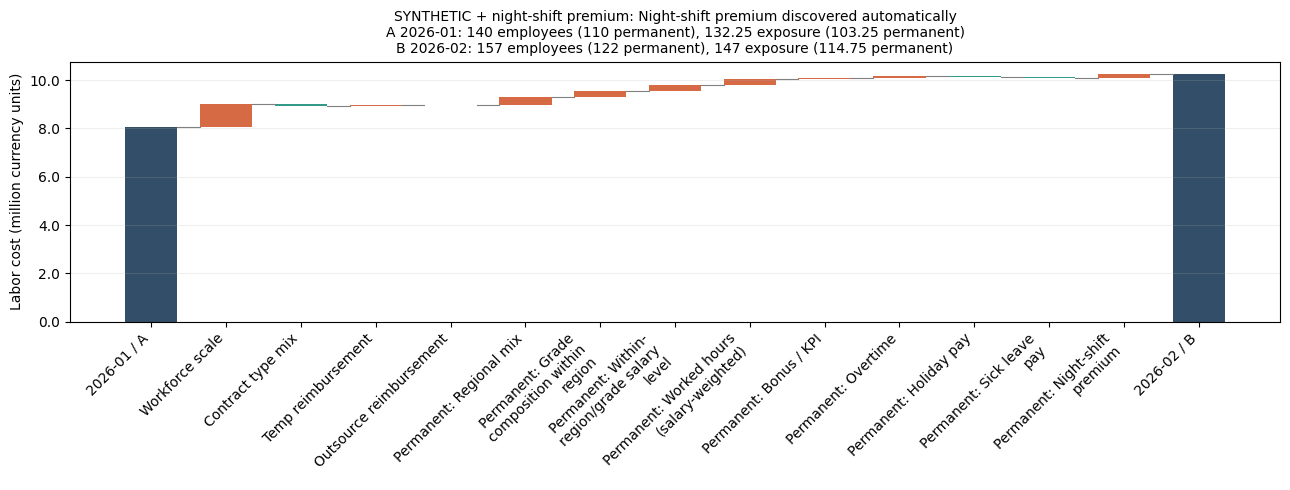

PASS: new eligible premium needs only its source payroll and one registration.


**SYNTHETIC + night-shift premium — Within-region/grade salary level: headline and audit**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: total-cost currency.*

headline_salary_impact   238,242.432632
sum_of_cell_impacts      238,242.432632
audit_error                    0.000000
dtype: float64

**SYNTHETIC + night-shift premium — Salary contribution by region × grade cell**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: counts; pre-regional salary per exposure; unit_impact per permanent exposure; total_impact in total currency.*

,region,grade,count_A,salary_A,source_A,count_B,salary_B,source_B,salary_change,unit_impact,total_impact
0,Central,G1,20,"42,599.060000",observed cell,22,"44,828.020000",observed cell,"2,228.960000",365.080000,"39,793.340000"
1,Central,G2,27,"59,662.830000",observed cell,17,"60,566.980000",observed cell,904.160000,146.160000,"15,931.620000"
2,Central,G3,32,"82,361.990000",observed cell,26,"87,612.940000",observed cell,"5,250.940000","1,146.940000","125,017.230000"
3,Coastal,G1,15,"42,261.610000",observed cell,8,"43,463.170000",observed cell,"1,201.560000",118.890000,"12,959.090000"
4,Coastal,G2,16,"58,775.510000",observed cell,12,"60,351.390000",observed cell,"1,575.880000",189.120000,"20,613.590000"
5,Coastal,G3,0,"82,361.990000",grade,12,"85,072.870000",observed cell,"2,710.870000",133.760000,"14,580.140000"
6,North,G1,0,"42,458.890000",grade,9,"42,105.060000",observed cell,-353.830000,-14.260000,"-1,554.550000"
7,North,G2,0,"59,327.990000",grade,8,"64,820.400000",observed cell,"5,492.400000",203.330000,"22,163.390000"
8,North,G3,0,"82,361.990000",grade,8,"79,497.440000",observed cell,"-2,864.560000",-103.320000,"-11,261.420000"


...

,employee_id,region_A,grade_A,base_salary_A,region_B,grade_B,base_salary_B,base_salary_change,salary_changed,grade_changed,region_changed
0,permanent-0012,Central,G3,"69,914.841324",Coastal,G2,"62,090.861325","-7,823.980000",True,True,True
1,permanent-0013,Coastal,G1,"36,596.355746",North,G1,"48,736.872936","12,140.517190",True,False,True
2,permanent-0014,Coastal,G1,"43,096.353437",Coastal,G3,"96,711.147947","53,614.794510",True,True,False
3,permanent-0015,Central,G3,"81,861.405097",North,G3,"75,563.076762","-6,298.328334",True,False,True
4,permanent-0016,Coastal,G1,"38,052.456277",Central,G3,"98,054.224141","60,001.767864",True,True,True
5,permanent-0017,Coastal,G2,"65,080.350309",Coastal,G1,"49,597.434804","-15,482.915505",True,True,False
6,permanent-0018,Central,G2,"61,490.256796",Central,G2,"66,849.586627","5,359.329830",True,False,False
7,permanent-0019,Central,G2,"62,112.351330",Central,G1,"42,430.398347","-19,681.952983",True,True,False
8,permanent-0020,Coastal,G2,"53,152.130332",North,G2,"71,263.650634","18,111.520302",True,False,True
9,permanent-0021,Central,G2,"52,671.785067",Coastal,G3,"92,232.122785","39,560.337717",True,True,True


**SYNTHETIC + night-shift premium — Entered permanent sample — showing 10 of 24**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: employee records; pre-regional base salary per exposure.*

,employee_id,region,grade,base_salary
238,permanent-0110,Central,G3,"96,595.964375"
239,permanent-0111,Central,G3,"86,177.259807"
240,permanent-0112,North,G2,"57,896.387632"
241,permanent-0113,Central,G1,"41,736.128228"
242,permanent-0114,Coastal,G2,"67,577.921555"
243,permanent-0115,Central,G1,"38,354.244668"
244,permanent-0116,Coastal,G2,"63,016.215699"
245,permanent-0117,Central,G3,"86,193.451152"
246,permanent-0118,Coastal,G1,"47,859.094260"
247,permanent-0119,Central,G3,"96,804.642398"


**SYNTHETIC + night-shift premium — Left permanent sample — showing 10 of 12**  
A 2026-01: 140 employees (110 permanent), 132.25 exposure (103.25 permanent) · B 2026-02: 157 employees (122 permanent), 147 exposure (114.75 permanent)

*Units: employee records; pre-regional base salary per exposure.*

,employee_id,region,grade,base_salary
0,permanent-0000,Coastal,G1,"36,876.612412"
1,permanent-0001,Central,G2,"67,166.936554"
2,permanent-0002,Central,G3,"80,398.123525"
3,permanent-0003,Coastal,G1,"45,912.130800"
4,permanent-0004,Central,G3,"72,357.561573"
5,permanent-0005,Central,G1,"46,855.402736"
6,permanent-0006,Central,G2,"51,392.575367"
7,permanent-0007,Central,G2,"58,516.025209"
8,permanent-0008,Central,G2,"51,891.132572"
9,permanent-0009,Central,G3,"81,276.985107"


In [17]:
# Existing APIs, unchanged.
extended_A, extended_fa, extended_ca = build_state(extended_employees,PERIOD_A,policy,EXTENDED_DRIVERS)
extended_B, extended_fb, extended_cb = build_state(extended_employees,PERIOD_B,policy,EXTENDED_DRIVERS)
extended = decompose(extended_A,extended_B,EXTENDED_DRIVERS)
extended_context = result_context(extended_employees, 'SYNTHETIC + night-shift premium')
show_result(reconcile(extended_employees,extended_A,extended_B,extended['permanent'],extended['top'],
                  extended['multiplier'],extended['bridge'],registry=EXTENDED_DRIVERS),
            extended_context, 'Analytical reconciliation', 'currency, permanent-unit currency, or exposure as named in each check')
show_result(extended['bridge'], extended_context, 'Final hierarchical bridge', 'total-cost currency; shares of net cost change')
extended_fallbacks = pd.concat([extended_fa,extended_fb],ignore_index=True)
show_result(extended_fallbacks.loc[extended_fallbacks.variable.eq('night_shift_premium')],
            extended_context, 'New premium fallbacks', 'pre-regional currency per exposure')
show_result(unsupported_mass(extended_A,extended_B,extended_ca,extended_cb,EXTENDED_DRIVERS),
            extended_context, 'Unsupported counterfactual cells', 'cell counts and permanent-composition shares')
show_result(pd.DataFrame({name:audit_coalitions(extended[name]) for name in ('permanent','top','auxiliary')}).T,
            extended_context, 'All-coalition validity', 'coalition counts; unit/total currency according to game')
assert 'night_shift_premium' in extended['permanent']['impacts'].index
assert 'night_shift_premium' in set(extended['bridge'].driver)
assert 'night_shift_premium' in set(extended_fallbacks.variable)
assert extended['permanent']['impacts']['night_shift_premium'] > 0
check_vector('original source and registry remain reusable', decompose(state_A,state_B)['bridge'].impact, bridge.impact)
_ = waterfall(extended['bridge'],extended['top']['base'],extended['top']['end'], 'Night-shift premium discovered automatically', context=extended_context)

# A newly eligible component is also discovered by the existing normalization helper.
adjusted_extension = extended_employees.copy()
adjusted_extension.loc[extended_permanent,'night_shift_premium'] *= adjusted_extension.loc[extended_permanent,'region'].map(REGIONAL_COEFFICIENTS)
normalized_extension = normalize_regional_inputs(adjusted_extension,policy,('night_shift_premium',),EXTENDED_DRIVERS)
pd.testing.assert_frame_equal(normalized_extension,extended_employees,rtol=RTOL,atol=ATOL)
print('PASS: new eligible premium needs only its source payroll and one registration.')

extended_salary_audit, extended_matches = show_salary_diagnostics(extended_employees,extended_A,extended_B,
    extended['permanent'],extended['multiplier'],extended_ca,extended_cb,extended_fa,extended_fb,extended_context,EXTENDED_DRIVERS)


## 14. Future planning / optimization reuse and review
An optimizer could construct a state directly, holding policy and unit-pay assumptions fixed
while choosing (N), the contract-share vector, regional shares, and each conditional-grade row.
It would call `cost(candidate_state)` without employee histories or SHAP. Probability constraints
are already validated. Business constraints would additionally cover service capacity, minimum
staffing, contract limits, regional/grade availability, quality, and hiring/movement limits.
Worked-time assumptions and sparse-cell pay references would need analyst approval as planning
inputs; an imputed feasible numerical cell is not proof of operational feasibility. No optimizer
is implemented here.

**Review of the delivered PoC:**

- **Analytical reconciliation:** independent synthetic row payroll and aggregate modeled costs
  reconcile for each contract and period; both SHAP levels and the final bridge reconcile.
  The mock reconciles against a clearly labeled reconstructed reference.
- **Counterfactual validity:** distributions switch as whole objects; fixed coefficients are
  derived inside payroll; all coalitions are validated; sparse-cell assumptions remain visible.
  Salary-weighted time and joint bonus/KPI payout preserve employee-level products. Eligible
  payment fallbacks use pre-regional units and receive the destination coefficient only in costing.
- **Driver extensibility:** the premium demonstration changes only source data/payroll and one
  registry entry including regional eligibility; the existing pipeline discovers it automatically. Salary rules
  remain a short, explicit formula rather than a generic expression language.
- **Abstraction:** one small driver dataclass and plain functions/dictionaries; no service,
  persistence, workflow framework, or optimizer. The exact-game limit is deliberate.

Remaining interpretation limits: no causal claims, no identifiable CR, no fabricated grade
coefficient, and fallback-dependent attribution in sparse populations. Revisit payroll assumptions
and inspect fallback exposure before drawing business conclusions.

In [18]:
assert validation.passed.all()
print('PASS: base and extended source reconciliation, both SHAP levels, hierarchical bridge,')
print('all coalition states, sparse fallbacks, regional adjustment, normalization, and driver extensibility.')

PASS: base and extended source reconciliation, both SHAP levels, hierarchical bridge,
all coalition states, sparse fallbacks, regional adjustment, normalization, and driver extensibility.
